# PLS Fine-Tuning on Google Colab L4 (Stable Stack, No Unsloth)

This notebook trains a **Plain-Language Summary (PLS)** generator using a **stable TRL + PEFT (QLoRA)** stack.
It is tailored for **Google Colab with NVIDIA L4**.

**Highlights**
- Versions pinned: `transformers==4.57.1`, `trl==0.23.1`, `peft==0.13.2`, `bitsandbytes>=0.43`, `datasets>=2.19`
- Model: `Qwen/Qwen2.5-3B-Instruct` (or 7B if VRAM allows)
- Format: **prompt–completion**; TRL 0.23 auto-masks the prompt (loss only on completion)
- English-only PLS with readability constraints (via system prompt)
- Optional: mount Google Drive to load your CSVs: **`pls_train_pairs.csv`, `pls_test_pairs.csv`** with columns `article,summary`

---


## 0) GPU & environment check

In [1]:

import torch, platform, sys
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.8.0+cu126
CUDA available: True
GPU: NVIDIA L4
Compute capability: (8, 9)


## 1) Install pinned dependencies (run once)

In [2]:
# 0) Remove typical conflict sources (safe to remove if you don't explicitly need them here)
%pip uninstall -y numpy pandas pyarrow scipy scikit-learn numba \
  cudf-cu12 dask-cudf-cu12 pylibcudf-cu12 cupy-cuda12x \
  opencv-python opencv-python-headless

# 1) Pin the low-level stack WITHOUT letting pip auto-upgrade others
%pip install -U --no-cache-dir --force-reinstall --no-deps \
  "numpy==2.1.3" "pandas==2.2.2" "pyarrow==18.1.0" "scipy==1.13.1"

# 2) Now install your ML/NLP deps on top
%pip install -U --no-cache-dir \
  "scikit-learn==1.5.2" \
  "unsloth>=2025.1.0" \
  "transformers==4.57.1" \
  "trl==0.23.1" \
  "peft==0.13.2" \
  "accelerate>=0.33" \
  "bitsandbytes>=0.43" \
  "datasets>=2.19" \
  "evaluate>=0.4.2" \
  "textstat>=0.7" \
  "bert-score>=0.3.13"


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: cudf-cu12 25.10.0
Uninstalling cudf-cu12-25.10.0:
  Successfully uninstalled cudf-cu12-25.10.0
Found existing installation: dask-cudf-cu12 25.10.0
Uninstalling dask-cudf-cu12-25.10.0:
  Successfully uninstalled dask-cudf-cu12-25.10.0
Found existing installation: pylibcudf-cu12 25.10.0
Uninstalli

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 249.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of unsloth to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 300.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 275.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 275.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 kB 305.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.0/59.0 kB 305.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 286.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 278.5 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of unsloth to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 

## 2) (Optional) Mount Google Drive

In [3]:

USE_DRIVE = True  # set False if your CSVs are in /content
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


## 3) Locate data (CSV)

In [1]:
import unsloth

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


    PyTorch 2.9.0+cu130 with CUDA 1300 (you have 2.9.0+cu128)
    Python  3.10.19 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


Switching to SDPA PyTorch native attention which is slightly slower.

Unsloth: Xformers was not installed correctly.
Please install xformers separately first.
Then confirm if it's correctly installed by running:
python -m xformers.info

Longer error message:
xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.9.0+cu130 with CUDA 1300 (you have 2.9.0+cu128)
    Python  3.10.19 (you have 3.12.12)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
from pathlib import Path
import pandas as pd

In [ ]:



# Expected CSVs: pls_train_pairs.csv, pls_test_pairs.csv with columns: article, summary
CANDIDATES = [
    Path('/content/drive/MyDrive/pls_agent/data'),
    Path('/content/data'),
    Path('/content'),
]

DATA_DIR = next((p for p in CANDIDATES if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Create a folder with your CSVs or update CANDIDATES.")

TRAIN_CSV = DATA_DIR / 'pls_train_pairs.csv'
TEST_CSV  = DATA_DIR / 'pls_test_pairs.csv'

def load_csv_safe(p: Path) -> pd.DataFrame:
    for sep in [",",";","\t","|"]:
        for enc in ["utf-8","utf-8-sig","latin-1"]:
            try:
                df = pd.read_csv(p, sep=sep, encoding=enc, on_bad_lines="skip")
                if df.shape[1] >= 2:
                    df.columns = [c.strip().lower() for c in df.columns]
                    return df
            except Exception:
                pass
    raise ValueError(f"Could not parse CSV: {p}")

if TRAIN_CSV.exists() and TEST_CSV.exists():
    raw_train = load_csv_safe(TRAIN_CSV)
    raw_test  = load_csv_safe(TEST_CSV)
else:
    print("CSV files not found; creating a tiny toy dataset to proceed.")
    raw_train = pd.DataFrame({
        "article":[
            "Objective: Evaluate dietary supplements on cognition in older adults. Methods and results omitted.",
            "Background: Dementia affects memory and daily life. This study compares stopping versus continuing drugs."
        ],
        "summary":[
            "The review looked at supplements and thinking in older adults. It did not show clear benefits. More complete results are needed to judge effects. The authors suggest cautious interpretation.",
            "The trials suggest stopping treatment may slightly worsen thinking and daily function. Continuing drugs might help maintain abilities for some time. Effects vary by person and disease stage. More long studies are needed."
        ]
    })
    raw_test = raw_train.copy()

print("Raw train:", raw_train.shape, "Raw test:", raw_test.shape)
print(raw_train.head(2))


Raw train: (84908, 5) Raw test: (4535, 5)
                                        non_pls_path  \
0  bridging-the-gap-in-health-literacy-main/data_...   
1  bridging-the-gap-in-health-literacy-main/data_...   

                                            pls_path  \
0  bridging-the-gap-in-health-literacy-main/data_...   
1  bridging-the-gap-in-health-literacy-main/data_...   

                                        non_pls_text  \
0  Background\nApproximately 70% of women will ex...   
1  Background\nApproximately 70% of women will ex...   

                                            pls_text  \
0  Absorbable stitches for repair of episiotomy a...   
1  Absorbable stitches for repair of episiotomy a...   

                          base_id  
0  10.1002-14651858.CD000006.pub2  
1  10.1002-14651858.CD000006.pub2  


## 4) Clean & normalize to (article, summary)

In [ ]:
# SINGLE-CELL PLS DATA PREP + SPLIT + SAVE TO GOOGLE DRIVE
# --------------------------------------------------------
# Dependencies
!pip -q install textstat

import os, json, re, hashlib, time
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import textstat as ts

# 0) Mount Google Drive (Colab)
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
except Exception as _:
    pass  # not running in Colab

# 1) CONFIG  --------------------------------------------------------------
# Where to save outputs (timestamped run folder)
ROOT_OUT = "/content/drive/MyDrive/pls_agent/datasets"
RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = os.path.join(ROOT_OUT, f"pls_prep_{RUN_STAMP}")
os.makedirs(OUT_DIR, exist_ok=True)

# Optional CSV inputs (if you don't already have raw_train/raw_test variables defined)
# Expect at least two text columns, e.g. ('article','summary') or any alias pair
TRAIN_INPUT_CSV = ""  # e.g., "/content/drive/MyDrive/pls_agent/raw_train.csv"
VAL_INPUT_CSV   = ""  # e.g., "/content/drive/MyDrive/pls_agent/raw_val.csv"

# Column alias pairs (first is article/source; second is summary/PLS)
ALIASES = [
    ("article","summary"),
    ("non_pls_text","pls_text"),
    ("source","target"),
    ("text","pls"),
    ("input","output"),
]

# Readability target thresholds
TARGETS = {
    'flesch_reading_ease': ('min', 60.0),
    'flesch_kincaid_grade': ('max', 6.0),
    'coleman_liau_index': ('max', 8.0),
    'gunning_fog': ('max', 8.0),
    'smog_index': ('max', 8.0),
    'dale_chall_score': ('max', 8.0),
}

# Tolerances & extra quality gates
TOL_PCT = 0.10                 # 10% margin around thresholds
SENT_LEN_RANGE = (12, 16)      # avg words per sentence
SENT_LEN_TOL = 2               # +/- words tolerance
COMPRESSION_RANGE = (0.08, 0.30)  # len(summary)/len(article)
MIN_NUMBER_RECALL = 0.80
MAX_REPETITION_RATIO = 0.15
MAX_JARGON_DENSITY = 0.08
MEDICAL_JARGON_HINTS = {
    "etiology","pathophysiology","comorbidity","morbidity","adverse","intervention",
    "randomized","placebo","biomarker","cohort","hazard","endpoint","efficacy",
    "incidence","prevalence","contraindication","pharmacokinetics","titration",
}

# Split & sampling knobs
VAL_RATIO = 0.10               # 10% validation
KEEP_NEARMISS = True
NEARMISS_FRACTION = 0.10       # take 10% of total as lowest-score failures

# 2) HELPERS  -------------------------------------------------------------
def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    cols = set(df.columns)
    for a, b in ALIASES:
        if a in cols and b in cols:
            return df[[a, b]].rename(columns={a: "article", b: "summary"}).copy()
    # fallback by median length
    lens = {c: df[c].astype(str).str.len().median() for c in df.columns}
    art  = max(lens, key=lens.get)
    summ = min(lens, key=lens.get)
    return df[[art, summ]].rename(columns={art: "article", summ: "summary"}).copy()

def clean_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["article"] = out["article"].astype(str).str.strip()
    out["summary"] = out["summary"].astype(str).str.strip()
    out.replace({"": np.nan, "nan": np.nan, "None": np.nan}, inplace=True)
    out.dropna(subset=["article", "summary"], inplace=True)
    out = out[out["article"].str.len() > 30]
    out = out[out["summary"].str.len() > 20]
    return out.reset_index(drop=True)

def tokenize(text):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|\d+(?:\.\d+)?", text.lower())

def words_per_sentence(text: str) -> float:
    sents = max(1, ts.sentence_count(text))
    words = max(1, ts.lexicon_count(text, removepunct=True))
    return words / sents

def numbers_in(text):
    return set(re.findall(r"\d+(?:\.\d+)?", text))

def number_recall(article, summary):
    art_nums = numbers_in(article)
    if not art_nums:
        return 1.0
    hit = sum(1 for n in art_nums if n in summary)
    return hit / len(art_nums)

def repetition_ratio(text):
    toks = tokenize(text)
    if not toks:
        return 0.0
    counts = Counter(toks)
    return max(counts.values()) / len(toks)

def jargon_density(text):
    toks = tokenize(text)
    if not toks:
        return 0.0
    long_words = sum(1 for w in toks if len(w) >= 12)
    hints     = sum(1 for w in toks if w in MEDICAL_JARGON_HINTS)
    return (long_words + hints) / len(toks)

def readability_metrics(text):
    return {
        'flesch_reading_ease':   ts.flesch_reading_ease(text),
        'flesch_kincaid_grade':  ts.flesch_kincaid_grade(text),
        'coleman_liau_index':    ts.coleman_liau_index(text),
        'gunning_fog':           ts.gunning_fog(text),
        'smog_index':            ts.smog_index(text),
        'dale_chall_score':      ts.dale_chall_readability_score(text),
    }

def within_with_tolerance(value, mode, thr, tol_pct):
    if mode == 'min':
        return value >= thr * (1 - tol_pct)
    else:
        return value <= thr * (1 + tol_pct)

def score_distance(value, mode, thr):
    if mode == 'min':
        gap = value - thr
        return gap if gap >= 0 else (abs(gap) ** 2 + 5.0)
    else:
        gap = thr - value
        return gap if gap >= 0 else (abs(gap) ** 2 + 5.0)

def evaluate_pair(article: str, summary: str, tol_pct=TOL_PCT):
    m = readability_metrics(summary)
    read_pass = all(
        within_with_tolerance(m[k], mode, thr, tol_pct)
        for k, (mode, thr) in TARGETS.items()
    )
    wps = words_per_sentence(summary)
    lo, hi = SENT_LEN_RANGE
    style_pass = (lo - SENT_LEN_TOL) <= wps <= (hi + SENT_LEN_TOL)

    comp = len(summary) / max(1, len(article))
    comp_pass = COMPRESSION_RANGE[0] <= comp <= COMPRESSION_RANGE[1]

    num_rec = number_recall(article, summary)
    numbers_pass = num_rec >= MIN_NUMBER_RECALL

    rep = repetition_ratio(summary)
    rep_pass = rep <= MAX_REPETITION_RATIO

    jarg = jargon_density(summary)
    jargon_pass = jarg <= MAX_JARGON_DENSITY

    pass_bool = all([read_pass, style_pass, comp_pass, numbers_pass, rep_pass, jargon_pass])

    dist = 0.0
    for k, (mode, thr) in TARGETS.items():
        dist += score_distance(m[k], mode, thr)
    if wps < lo: dist += (lo - wps) ** 2 * 0.2
    elif wps > hi: dist += (wps - hi) ** 2 * 0.2
    if comp < COMPRESSION_RANGE[0]:
        dist += (COMPRESSION_RANGE[0] - comp) * 10
    elif comp > COMPRESSION_RANGE[1]:
        dist += (comp - COMPRESSION_RANGE[1]) * 10
    dist += (1 - num_rec) * 5.0
    dist += max(0.0, rep - MAX_REPETITION_RATIO) * 20.0
    dist += max(0.0, jarg - MAX_JARGON_DENSITY) * 10.0

    metrics = {
        **m,
        'avg_words_per_sentence': wps,
        'compression_ratio': comp,
        'number_recall': num_rec,
        'repetition_ratio': rep,
        'jargon_density': jarg,
    }
    return {'pass_bool': pass_bool, 'score': float(dist), 'metrics': metrics}

def evaluate_dataframe(df: pd.DataFrame, tol_pct=TOL_PCT):
    rows = []
    for _, r in df[['article','summary']].iterrows():
        res = evaluate_pair(r['article'], r['summary'], tol_pct=tol_pct)
        rows.append({
            **res['metrics'],
            'pass_bool': res['pass_bool'],
            'score': res['score'],
        })
    scored = pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    best = scored[scored['pass_bool']].sort_values('score').reset_index(drop=True)
    return scored, best

def to_jsonl(df: pd.DataFrame, path: str):
    with open(path, "w", encoding="utf-8") as f:
        for _, r in df.iterrows():
            f.write(json.dumps({"article": r["article"], "summary": r["summary"]}, ensure_ascii=False))
            f.write("\n")

def norm_text(t: str) -> str:
    return " ".join(str(t).lower().split())

def sha1(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8")).hexdigest()

def hash_split(df: pd.DataFrame, val_ratio=VAL_RATIO):
    df = df.copy()
    df["article_norm"] = df["article"].map(norm_text)
    df["group_id"] = df["article_norm"].map(sha1)

    def is_val(gid: str, ratio=val_ratio) -> bool:
        bucket = int(gid[:8], 16) % 100
        return bucket < int(ratio * 100)

    df["split"] = df["group_id"].map(lambda g: "val" if is_val(g) else "train")
    return df

# 3) LOAD INPUTS  ---------------------------------------------------------
def load_inputs():
    # Use existing variables if present; else try CSV; else raise.
    global raw_train, raw_test
    if 'raw_train' in globals() and 'raw_test' in globals():
        rt = raw_train.copy()
        rv = raw_test.copy()
    else:
        if not TRAIN_INPUT_CSV or not VAL_INPUT_CSV:
            raise ValueError(
                "Please define 'raw_train' and 'raw_test' dataframes OR set TRAIN_INPUT_CSV and VAL_INPUT_CSV paths."
            )
        rt = pd.read_csv(TRAIN_INPUT_CSV)
        rv = pd.read_csv(VAL_INPUT_CSV)
    return rt, rv



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.4 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
raw_train_df, raw_val_df = load_inputs()

# 4) NORMALIZE + CLEAN  ---------------------------------------------------
train_df = normalize_cols(raw_train_df)
val_df   = normalize_cols(raw_val_df)
train_df = clean_df(train_df)
val_df   = clean_df(val_df)

print("After normalization & cleaning ->",
      "train:", train_df.shape, "val:", val_df.shape)

# 5) EVALUATE & RANK  -----------------------------------------------------
scored_train, best_train = evaluate_dataframe(train_df, tol_pct=TOL_PCT)
scored_val,   best_val   = evaluate_dataframe(val_df,   tol_pct=TOL_PCT)

# (Optional) keep near-misses
if KEEP_NEARMISS:
    near_train = scored_train[~scored_train["pass_bool"]].nsmallest(
        int(NEARMISS_FRACTION * len(scored_train)), "score"
    )
    near_val = scored_val[~scored_val["pass_bool"]].nsmallest(
        max(1, int(NEARMISS_FRACTION * len(scored_val))), "score"
    )
    best_train_plus = pd.concat([best_train, near_train], axis=0).sort_values("score").reset_index(drop=True)
    best_val_plus   = pd.concat([best_val,   near_val],   axis=0).sort_values("score").reset_index(drop=True)
else:
    best_train_plus = best_train.copy()
    best_val_plus   = best_val.copy()

# 6) LEAK-SAFE SPLIT (by article hash)  -----------------------------------
# Combine and split so that duplicates don't leak across splits
combined = pd.concat([best_train_plus.assign(src="train_raw"),
                      best_val_plus.assign(src="val_raw")], axis=0, ignore_index=True)

combined_split = hash_split(combined, val_ratio=VAL_RATIO)
train_split = combined_split[combined_split["split"] == "train"].reset_index(drop=True)
val_split   = combined_split[combined_split["split"] == "val"].reset_index(drop=True)

# Keep only fields for training
train_out = train_split[["article", "summary"]].copy()
val_out   = val_split[["article", "summary"]].copy()

print(f"Final sizes -> TRAIN: {len(train_out)}  |  VAL: {len(val_out)}")

# 7) SAVE ARTIFACTS  ------------------------------------------------------
# Core training files
to_jsonl(train_out, os.path.join(OUT_DIR, "pls_train.jsonl"))
to_jsonl(val_out,   os.path.join(OUT_DIR, "pls_val.jsonl"))
train_out.to_csv(os.path.join(OUT_DIR, "pls_train.csv"), index=False)
val_out.to_csv(os.path.join(OUT_DIR, "pls_val.csv"), index=False)

# Diagnostics: full scored inputs & summary metrics
scored_train.to_csv(os.path.join(OUT_DIR, "scored_train_full.csv"), index=False)
scored_val.to_csv(  os.path.join(OUT_DIR, "scored_val_full.csv"),   index=False)

summary = {
    "run_stamp": RUN_STAMP,
    "input_sizes": {
        "raw_train_rows": len(raw_train_df),
        "raw_val_rows":   len(raw_val_df),
    },
    "cleaned_sizes": {
        "train": len(train_df),
        "val":   len(val_df),
    },
    "pass_counts": {
        "train_pass": int(best_train.shape[0]),
        "val_pass":   int(best_val.shape[0]),
    },
    "final_splits": {
        "train": int(len(train_out)),
        "val":   int(len(val_out)),
        "val_ratio": VAL_RATIO,
    },
    "config": {
        "targets": TARGETS,
        "tol_pct": TOL_PCT,
        "sent_len_range": SENT_LEN_RANGE,
        "sent_len_tol": SENT_LEN_TOL,
        "compression_range": COMPRESSION_RANGE,
        "min_number_recall": MIN_NUMBER_RECALL,
        "max_repetition_ratio": MAX_REPETITION_RATIO,
        "max_jargon_density": MAX_JARGON_DENSITY,
        "keep_nearmiss": KEEP_NEARMISS,
        "nearmiss_fraction": NEARMISS_FRACTION,
    }
}
with open(os.path.join(OUT_DIR, "run_summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

# Quick human-readable summary
print("\n=== RUN SUMMARY ===")
for k, v in summary.items():
    print(k, ":", v)

print(f"\nSaved to: {OUT_DIR}")


In [ ]:
# Reload PLS CSVs produced by the prep pipeline
from pathlib import Path
import pandas as pd
import re

# 1) If you're using Drive
USE_DRIVE = True
if USE_DRIVE:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass

# 2) Where prep pipeline saved outputs
ROOT = Path("/content/drive/MyDrive/pls_agent/datasets")

# (A) Auto-pick the most recent "pls_prep_YYYYMMDD_HHMMSS" run
def latest_prep_dir(root: Path) -> Path:
    runs = [p for p in root.glob("pls_prep_*") if p.is_dir()]
    if not runs:
        raise FileNotFoundError(f"No prep runs found under {root}")
    # sort by timestamp in folder name
    runs_sorted = sorted(runs, key=lambda p: p.name, reverse=True)
    return runs_sorted[0]

# (B) Or set manually (uncomment to force a specific run)
# RUN_DIR = ROOT / "pls_prep_20251109_010634"

RUN_DIR = latest_prep_dir(ROOT)
print("Using run:", RUN_DIR)

TRAIN_CSV = RUN_DIR / "pls_train.csv"
VAL_CSV   = RUN_DIR / "pls_val.csv"

def load_csv(p: Path) -> pd.DataFrame:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")
    df = pd.read_csv(p)
    # expect article, summary (as written by the prep script)
    cols = [c.strip().lower() for c in df.columns]
    df.columns = cols
    assert "article" in df.columns and "summary" in df.columns, f"CSV must have 'article' and 'summary' columns; got {df.columns}"
    # drop empties
    df["article"] = df["article"].astype(str).str.strip()
    df["summary"] = df["summary"].astype(str).str.strip()
    df = df[(df["article"].str.len() > 0) & (df["summary"].str.len() > 0)].reset_index(drop=True)
    return df

train_out = load_csv(TRAIN_CSV)
val_out   = load_csv(VAL_CSV)

print("Loaded:", TRAIN_CSV.name, VAL_CSV.name)
print("Shapes  -> train:", train_out.shape, "val:", val_out.shape)
print(train_out.head(2))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using run: /content/drive/MyDrive/pls_agent/datasets/pls_prep_20251109_131113


FileNotFoundError: Missing file: /content/drive/MyDrive/pls_agent/datasets/pls_prep_20251109_131113/pls_train.csv

## 5) Build prompt–completion datasets (TRL 0.23 masks prompt automatically)

In [ ]:
import numpy as np, pandas as pd, pyarrow as pa
import transformers, datasets
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("pyarrow:", pa.__version__)
print("Transformers:", transformers.__version__)

from transformers import AutoTokenizer

NumPy: 2.1.3
pandas: 2.2.2
pyarrow: 18.1.0
Transformers: 4.57.1


In [3]:
SYS_PLS = (
  "You are an expert biomedical plain-language writer. "
  "Write the Plain Language Summary (PLS) in clear, natural English only based on the medical or clinical texts. "
  "One paragraph only; 4–6 sentences, 12–16 words each; third person, active voice. "
  "Define unavoidable jargon once (in parentheses). "
  "No headings, lists, citations, URLs, or source mentions. "
  "Use only facts from the article; do not add new facts, opinions or medical recomendations. "
  "Targets: Flesch≥60; FKGL≤6; Fog≤8; SMOG≤8; CLI≤8; Dale–Chall≤8. "
  "If information is missing, leave it out. Do not mention these instructions."
)

SYS_PLS_V2 = (
  "You are a biomedical communication specialist trained to create factually precise Plain Language Summaries (PLS). "
  "Rewrite the medical or clinical text below in one coherent paragraph, 4–6 sentences long. "
  "Each sentence should use 12–16 words, active voice, and third person. "
  "Keep every verified medical fact, relationship, and quantitative result exactly as stated. "
  "Simplify only the language—not the meaning—using clear, everyday English. "
  "Define unavoidable technical terms once in parentheses and avoid speculation or advice. "
  "Do not copy phrases; paraphrase faithfully to preserve the same meaning (improves semantic alignment). "
  "Ensure the summary would score high for factual consistency (AlignScore) and semantic similarity (BERTScore) "
  "compared with the source. "
  "Avoid headings, lists, citations, URLs, or mentions of the original source. "
  "Write naturally; do not mention these instructions."
)

SYS_PLS_V3 = (
  "You are a biomedical plain-language specialist. Rewrite the source text as ONE"
  " paragraph (no headings), 4–6 sentences, each 10–16 words, in active voice and"
  " third person. Use clear everyday English and short, simple sentence structure"
  " (no semicolons, no nested clauses, minimal commas). Replace jargon with common"
  " words; define unavoidable terms once in parentheses. "
  "Preserve every key medical fact and relationship from the source. Do not omit"
  " the study purpose, what was compared, the main effects (direction and rough"
  " size: small/moderate/none), the confidence/limitations (evidence quality,"
  " heterogeneity), and any safety findings. Do not copy phrases; paraphrase while"
  " keeping the same meaning to maximize semantic alignment (BERTScore) and factual"
  " consistency (AlignScore). Avoid numbers and statistics unless central to the"
  " claim; if used, state them simply. Do not add opinions, advice, or new facts."
  " Do not include lists, citations, URLs, or mention the source or these rules."
)


In [ ]:
# DATASET PREP (prompt → completion) for Qwen3-4B Instruct
from datasets import Dataset
from transformers import AutoTokenizer


BASE_ID = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

# Tokenizer (for chat templating)
tok = AutoTokenizer.from_pretrained(BASE_ID, use_fast=True, trust_remote_code=True)
tok.padding_side = "right"
if tok.pad_token_id is None:
    tok.pad_token = tok.eos_token  # tie PAD→EOS if missing

def to_prompt_completion(df):
    prompts, completions = [], []
    for art, summ in zip(df["article"].astype(str), df["summary"].astype(str)):
        messages = [
            {"role": "system", "content": SYS_PLS},
            {"role": "user",   "content": art}
        ]
        # chat template + generation prompt -> pure prompt; completion is your gold PLS
        prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        prompts.append(prompt)
        completions.append(summ.strip())
    return Dataset.from_dict({"prompt": prompts, "completion": completions})

# Assumes you already created train_out / val_out (dataframes with columns: article, summary)
train_ds = to_prompt_completion(train_out)
val_ds   = to_prompt_completion(val_out)

print(train_ds[0])


## 6) Load model in 4-bit and attach LoRA (QLoRA)

In [ ]:
import torch
from unsloth import FastLanguageModel

# Load 4-bit base
model, tok = FastLanguageModel.from_pretrained(
    model_name     = BASE_ID,
    load_in_4bit   = True,
    max_seq_length = 4096,
    dtype          = torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map     = "auto",
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

# Qwen/Qwen2.x/Qwen3 projection names
QWEN_LORA_TARGETS = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "up_proj", "down_proj", "gate_proj",
]

# Attach LoRA — NOTE: pass a LIST, not a string
model = FastLanguageModel.get_peft_model(
    model,
    r=64,
    target_modules=QWEN_LORA_TARGETS,
    lora_alpha=16,
    lora_dropout=0.0,                 # keep 0.0 for Unsloth speed
    bias="none",
    use_gradient_checkpointing="unsloth",
)

model.print_trainable_parameters()


==((====))==  Unsloth 2025.9.5: Fast Qwen2 patching. Transformers: 4.57.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2025.9.5 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


trainable params: 119,734,272 || all params: 3,205,672,960 || trainable%: 3.7351


## 7) Train with TRL 0.23 (completion-only by default)

In [ ]:
# === CELL 3: SFTTrainer with robust loss hook (handles no-loss, signatures, and Unsloth view) ===
from trl import SFTTrainer, SFTConfig
from datetime import datetime
from pathlib import Path
import torch
import torch.nn.functional as F

run_stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = Path('/content/pls_sft_outputs') / run_stamp
output_dir.mkdir(parents=True, exist_ok=True)

# You are using prompt+completion columns → Unsloth needs a formatter
def formatting_func(batch):
    # Your prompts already end with the assistant tag due to add_generation_prompt=True
    return [p + c for p, c in zip(batch["prompt"], batch["completion"])]

def _shifted_ce_from_logits(logits, labels):
    """
    Compute standard causal LM cross-entropy with shift.
    labels should contain -100 where tokens must be ignored.
    """
    # [B, T, V] -> [B, T-1, V]; labels [B, T] -> [B, T-1]
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    return F.cross_entropy(
        shift_logits.reshape(-1, shift_logits.size(-1)),
        shift_labels.reshape(-1),
        ignore_index=-100,
    )

def universal_safe_loss(*args, **kwargs):
    """
    Works for BOTH call styles:
      A) HF Trainer:    compute_loss_func(outputs, labels, num_items_in_batch=?, ...)
      B) TRL/Unsloth:   compute_loss_func(model, inputs, return_outputs=?)
    Also clones the loss to avoid in-place scaling on a view (Unsloth fused loss).
    """
    # --- Case A: HF style (first arg is outputs, not a model) ---
    if len(args) >= 1 and not hasattr(args[0], "forward"):
        outputs = args[0]
        labels = None
        if len(args) >= 2:
            labels = args[1]
        else:
            labels = kwargs.get("labels", None)

        # Try to read precomputed loss
        if isinstance(outputs, dict):
            loss = outputs.get("loss", None)
            logits = outputs.get("logits", None)
        else:
            loss = getattr(outputs, "loss", None)
            logits = getattr(outputs, "logits", None)

        if loss is not None:
            return loss.clone()

        # Fallback: compute CE from logits + labels
        if logits is None or labels is None:
            raise ValueError("universal_safe_loss: need logits and labels to compute loss.")
        return _shifted_ce_from_logits(logits, labels)

    # --- Case B: TRL/Unsloth style (first arg is model) ---
    model = args[0]
    inputs = args[1]
    return_outputs = kwargs.get("return_outputs", False)

    outputs = model(**inputs)
    # Try loss first
    loss = None
    if isinstance(outputs, dict):
        loss = outputs.get("loss", None)
        logits = outputs.get("logits", None)
    else:
        loss = getattr(outputs, "loss", None)
        logits = getattr(outputs, "logits", None)

    if loss is None:
        labels = inputs.get("labels", None)
        if logits is None or labels is None:
            raise ValueError("universal_safe_loss: model returned no loss; need logits + labels.")
        loss = _shifted_ce_from_logits(logits, labels)

    loss = loss.clone()  # avoid in-place scaling on view
    return (loss, outputs) if return_outputs else loss

# Stability tweak
try:
    model.config.use_cache = False
except Exception:
    pass

cfg = SFTConfig(
    output_dir=str(output_dir),
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    bf16=torch.cuda.is_available(),
    logging_steps=10,
    save_strategy="epoch",
    save_total_limit=2,
    report_to=["tensorboard"],
    lr_scheduler_type="constant_with_warmup",
    warmup_ratio=0.05,
    max_seq_length=2048,
    packing=False,
    # With formatting_func, Unsloth expects training on the full sequence
    completion_only_loss=False,
    dataset_num_proc=2,
)

trainer = SFTTrainer(
    model=model,
    args=cfg,
    train_dataset=train_ds,   # columns: "prompt", "completion"
    eval_dataset=val_ds,
    tokenizer=tok,
    formatting_func=formatting_func,
    compute_loss_func=universal_safe_loss,
)

trainer.train()

adapter_dir = output_dir / "final_adapter"
trainer.save_model(str(adapter_dir))
tok.save_pretrained(str(adapter_dir))
print("Saved LoRA adapter + tokenizer to:", adapter_dir)


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/8031 [00:00<?, ? examples/s]

TimeoutError: 

In [ ]:
adapter_dir = "/content/drive/MyDrive/pls_agent/datasets/final_adapter"
trainer.save_model(str(adapter_dir))
tok.save_pretrained(str(adapter_dir))
print("Saved LoRA adapter + tokenizer to:", adapter_dir)

Saved LoRA adapter + tokenizer to: /content/drive/MyDrive/pls_agent/datasets/final_adapter


In [ ]:
import pandas as pd
from pathlib import Path

hist = pd.DataFrame(trainer.state.log_history)   # steps, loss, eval_loss, etc.
csv_path = Path(str(output_dir)) / "trainer_logs.csv"
hist.to_csv(csv_path, index=False)
print("Saved:", csv_path)

Saved: /content/pls_sft_outputs/20251109_030658/trainer_logs.csv


In [ ]:
import pandas as pd
from pathlib import Path

hist = pd.DataFrame(trainer.state.log_history)   # steps, loss, eval_loss, etc.
csv_path = Path(str(adapter_dir)) / "trainer_logs.csv"
hist.to_csv(csv_path, index=False)
print("Saved:", csv_path)

Saved: /content/drive/MyDrive/pls_agent/datasets/final_adapter/trainer_logs.csv


## 8) Inference sanity check (single paragraph, English only)

In [5]:

import re

def gen_pls(article: str, inference: bool = False) -> str:
    messages=[{"role":"system","content":SYS_PLS if inference else SYS_PLS},
              {"role":"user","content":article}]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=200, min_new_tokens=60,
            temperature=0.2, top_p=0.9,
            no_repeat_ngram_size=3, repetition_penalty=1.12,
            eos_token_id=tok.eos_token_id, pad_token_id=tok.pad_token_id
        )
    text = tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    text = " ".join(text.split())
    text = re.sub(r"\s*\n+\s*", " ", text).strip()
    return text

print(gen_pls("Objective: Evaluate dietary supplements on cognition in older adults. Methods and results omitted for brevity."))


Can vitamin and mineral supplements improve thinking skills in older people? Review question We reviewed evidence about the effect of vitamin and trace element supplements on thinking skills (cognition) in older children and adults. We looked at vitamins (including ascorbic acid), essential trace elements (zinc, selenium, iodine) and other minerals (sodium, calcium, copper, magnesium, phosphorus, potassium, silicon). Background The population we included in this review were healthy people aged 65 years and over. We also included people with memory problems who may be at risk of Alzheimer's disease. This was because some of the vitamins and minerals (e.g. vitamin B1, folic acid, niacin, vitamin B6, vitamin E, beta‐carotene) are used to treat dementia symptoms. Study characteristics We found 23 studies involving more than 9800 participants. The duration of treatment varied from one week to up to two years.


In [ ]:
%%time
# --- Celda 5.1: Prueba Unitaria de Generación de Resúmenes ---

# Seleccionar un ejemplo del dataset de prueba para la verificación
# Puedes cambiar el índice (ej. [10], [25], [50]) para probar diferentes textos
#sample_index = 25
#sample_example = test_dataset[sample_index]

print("="*80)
print(f"--- INICIANDO PRUEBA UNITARIA CON EL EJEMPLO #{1} ---")
print("="*80)

# Extraer los textos del ejemplo
technical_text_sample = res_df.loc[res_df.index[0], "source"]
#reference_summary_sample = sample_example['plain_summary']

print("\n\033[1m1. TEXTO TÉCNICO ORIGINAL (PRIMEROS 1000 CARACTERES):\033[0m")
print("-"*50)
print(technical_text_sample[:1000] + "...")
print("-"*50)

print("\n\033[1m2. RESUMEN DE REFERENCIA (HUMANO):\033[0m")
print("-"*50)
#print(reference_summary_sample)
print("-"*50)

# Generar el resumen usando la función que ya definiste
print("\nGenerando resumen con el modelo afinado...")
generated_summary_sample = gen_pls(technical_text_sample)

print("\n\033[1m3. RESUMEN GENERADO POR EL MODELO (MedGemma Fine-Tuned):\033[0m")
print("-"*50)
print(generated_summary_sample)
print("-"*50)

print("\n\033[92m--- PRUEBA UNITARIA COMPLETADA ---\033[0m")
print("Verifica visualmente si el resumen generado es coherente, fiel al texto y está en lenguaje sencillo.")

--- INICIANDO PRUEBA UNITARIA CON EL EJEMPLO #1 ---

1. TEXTO TÉCNICO ORIGINAL (PRIMEROS 1000 CARACTERES):
--------------------------------------------------
Background
Lumbar spinal stenosis with neurogenic claudication is one of the most commonly diagnosed and treated pathological spinal conditions. It frequently afflicts the elderly population. 
Objectives
To systematically review the evidence for the effectiveness of nonoperative treatment of lumbar spinal stenosis with neurogenic claudication. 
Search methods
CENTRAL, MEDLINE, CINAHL, and Index to Chiropractic Literature (ICL) databases were searched up to June 2012. 
Selection criteria
Randomized controlled trials published in English, in which at least one arm provided data on nonoperative treatments 
Data collection and analysis
We used the standard methodological procedures expected by The Cochrane Collaboration. Risk of bias in each study was independently assessed by two review authors using the 12 criteria recommended by th

In [ ]:
generated_summary_sample

"What are the benefits and risks of non‐surgical treatment for people with lumbar stenonia with nerve irritation (sciatica)? Background {#S0001} ============ The lower back can become inflamed because of damage to the bones, discs and nerves around the joints. This is called 'lumbar stentoroma'. The symptoms are numbness, tingling, weakness and pain in the legs. Usually this condition affects older people who may have had repeated episodes of kidney stones or osteoporosis ('porcelain' bones). The usual treatment is drug treatment or activity restriction, or surgery to relieve pressure on the nerves. Surgery usually involves implanting a metal tube into the space between the vertebrae to relieve tension. Study characteristics {#jvza12448-sec1} -------------------- In this review we set out to examine the evidence about the benefits of non‑surgical treatments including medication, physiotherapy, exercises, spine zone"

## 9) (Optional) Best-of-3 with readability reranker

In [ ]:

import math, textstat

TARGETS = {
    'flesch_reading_ease': ('min', 60.0),
    'flesch_kincaid_grade': ('max', 6.0),
    'coleman_liau_index': ('max', 8.0),
    'gunning_fog': ('max', 8.0),
    'smog_index': ('max', 8.0),
    'dale_chall_score': ('max', 8.0),
}
def readability_report(t: str):
    return {
        'flesch_reading_ease': float(textstat.flesch_reading_ease(t)),
        'flesch_kincaid_grade': float(textstat.flesch_kincaid_grade(t)),
        'coleman_liau_index': float(textstat.coleman_liau_index(t)),
        'gunning_fog': float(textstat.gunning_fog(t)),
        'smog_index': float(textstat.smog_index(t)),
        'dale_chall_score': float(textstat.dale_chall_readability_score(t)),
    }
def margin_score(scores: dict) -> float:
    pc, s = 0, 0.0
    for m,(mode,t) in TARGETS.items():
        v = scores.get(m, float('nan'))
        if math.isnan(v): continue
        margin = (v - t) if mode=='min' else (t - v)
        if margin >= 0: pc, s = pc+1, s + min(margin, 20.0)
        else: s += margin
    return pc*1000.0 + s

def best_of_n(article: str, n=3) -> str:
    cands = [gen_pls(article) for _ in range(n)]
    ranked = sorted(((margin_score(readability_report(t)), t) for t in cands), reverse=True)
    return ranked[0][1]

print(best_of_n("This review compares stopping versus continuing cholinesterase inhibitors in Alzheimer’s disease.", n=3))


In [4]:
# === RELOAD LoRA ADAPTER (4-bit base) ===
import torch
from unsloth import FastLanguageModel
from peft import PeftModel
from transformers import AutoTokenizer

BASE_ID     = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"   # same base used for training
ADAPTER_DIR = "/content/drive/MyDrive/pls_agent/datasets/final_adapter"  # <-- your saved path

# 1) Load the quantized base via Unsloth
model, tok = FastLanguageModel.from_pretrained(
    model_name     = BASE_ID,
    load_in_4bit   = True,
    max_seq_length = 4096,
    dtype          = torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map     = "auto",
)

# 2) Load the tokenizer you saved with the adapter (keeps exact special tokens)
tok = AutoTokenizer.from_pretrained(ADAPTER_DIR, use_fast=True)

# 3) Attach LoRA weights
model = PeftModel.from_pretrained(model, ADAPTER_DIR)

# 4) Switch to inference fast-path (enables efficient generation kernels)
model = FastLanguageModel.for_inference(model)


==((====))==  Unsloth 2025.9.5: Fast Qwen2 patching. Transformers: 4.57.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

In [ ]:
manual_test = raw_test['non_pls_text'].sample(1).iloc[0]
print(manual_test)

manual_test="Background Communication is a common element in all medical consultations, affecting a range of outcomes for doctors and patients. The increasing demand for medical students to be trained to communicate effectively has seen the emergence of interpersonal communication skills as core graduate competencies in medical training around the world. Medical schools have adopted a range of approaches to develop and evaluate these competencies. Objectives To assess the effects of interventions for medical students that aim to improve interpersonal communication in medical consultations. Search methods We searched five electronic databases: Cochrane Central Register of Controlled Trials, MEDLINE, Embase, PsycINFO, and ERIC (Educational Resource Information Centre) in September 2020, with no language, date, or publication status restrictions. We also screened reference lists of relevant articles and contacted authors of included studies. Selection criteria We included randomised controlled trials (RCTs), cluster‐RCTs (C‐RCTs), and non‐randomised controlled trials (quasi‐RCTs) evaluating the effectiveness of interventions delivered to students in undergraduate or graduate‐entry medical programmes. We included studies of interventions aiming to improve medical students’ interpersonal communication during medical consultations. Included interventions targeted communication skills associated with empathy, relationship building, gathering information, and explanation and planning, as well as specific communication tasks such as listening, appropriate structure, and question style. Data collection and analysis We used standard methodological procedures expected by Cochrane. Two review authors independently reviewed all search results, extracted data, assessed the risk of bias of included studies, and rated the quality of evidence using GRADE. Main results We found 91 publications relating to 76 separate studies (involving 10,124 students): 55 RCTs, 9 quasi‐RCTs, 7 C‐RCTs, and 5 quasi‐C‐RCTs. We performed meta‐analysis according to comparison and outcome. Among both effectiveness and comparative effectiveness analyses, we separated outcomes reporting on overall communication skills, empathy, rapport or relationship building, patient perceptions/satisfaction, information gathering, and explanation and planning. Overall communication skills and empathy were further divided as examiner‐ or simulated patient‐assessed. The overall quality of evidence ranged from moderate to very low, and there was high, unexplained heterogeneity.Overall, interventions had positive effects on most outcomes, but generally small effect sizes and evidence quality limit the conclusions that can be drawn. Communication skills interventions in comparison to usual curricula or control may improve both overall communication skills (standardised mean difference (SMD) 0.92, 95% confidence interval (CI) 0.53 to 1.31; 18 studies, 1356 participants; I² = 90%; low‐quality evidence) and empathy (SMD 0.64, 95% CI 0.23 to 1.05; 6 studies, 831 participants; I² = 86%; low‐quality evidence) when assessed by experts, but not by simulated patients. Students’ skills in information gathering probably also improve with educational intervention (SMD 1.07, 95% CI 0.61 to 1.54; 5 studies, 405 participants; I² = 78%; moderate‐quality evidence), but there may be little to no effect on students' rapport (SMD 0.18, 95% CI ‐0.15 to 0.51; 9 studies, 834 participants; I² = 81%; low‐quality evidence), and effects on information giving skills are uncertain (very low‐quality evidence). We are uncertain whether experiential interventions improve overall communication skills in comparison to didactic approaches (SMD 0.08, 95% CI ‐0.02 to 0.19; 4 studies, 1578 participants; I² = 4%; very low‐quality evidence). Electronic learning approaches may have little to no effect on students’ empathy scores (SMD ‐0.13, 95% CI ‐0.68 to 0.43; 3 studies, 421 participants; I² = 82%; low‐quality evidence) or on rapport (SMD 0.02, 95% CI ‐0.33 to 0.38; 3 studies, 176 participants; I² = 19%; moderate‐quality evidence) compared to face‐to‐face approaches. There may be small negative effects of electronic interventions on information giving skills (low‐quality evidence), and effects on information gathering skills are uncertain (very low‐quality evidence). Personalised/specific feedback probably improves overall communication skills to a small degree in comparison to generic or no feedback (SMD 0.58, 95% CI 0.29 to 0.87; 6 studies, 502 participants; I² = 56%; moderate‐quality evidence). There may be small positive effects of personalised feedback on empathy and information gathering skills (low quality), but effects on rapport are uncertain (very low quality), and we found no evidence on information giving skills. We are uncertain whether role‐play with simulated patients outperforms peer role‐play in improving students’ overall communication skills (SMD 0.17, 95% CI ‐0.33 to 0.67; 4 studies, 637 participants; I² = 87%; very low‐quality evidence). There may be little to no difference between effects of simulated patient and peer role‐play on students' empathy (low‐quality evidence) with no evidence on other outcomes for this comparison. Descriptive syntheses of results that could not be included in meta‐analyses across outcomes and comparisons were mixed, as were effects of different interventions and comparisons on specific communication skills assessed by the included trials. Quality of evidence was downgraded due to methodological limitations across several risk of bias domains, high unexplained heterogeneity, and imprecision of results.In general, results remain consistent in sensitivity analysis based on risk of bias and adjustment for clustering. No adverse effects were reported."

Background
Water immersion during labour and birth is increasingly popular and is becoming widely accepted across many countries, and particularly in midwifery‐led care settings. However, there are concerns around neonatal water inhalation, increased requirement for admission to neonatal intensive care unit (NICU), maternal and/or neonatal infection, and obstetric anal sphincter injuries (OASIS). This is an update of a review last published in 2011. 
Objectives
To assess the effects of water immersion during labour and/or birth (first, second and third stage of labour) on women and their infants. 
Search methods
We searched Cochrane Pregnancy and Childbirth’s Trials Register, ClinicalTrials.gov and the WHO International Clinical Trials Registry Platform (ICTRP) (18 July 2017), and reference lists of retrieved trials. 
Selection criteria
We included randomised controlled trials (RCTs) comparing water immersion with no immersion, or other non‐pharmacological forms of pain management duri

In [ ]:
pls_test = gen_pls(manual_test, inference=True)

In [ ]:
print(pls_test)

What are the benefits of teaching medical students how to talk to patients? Review question We aimed to find out if teaching medicalstudents basic communication skills helps them when they start working as doctors. We measured the impact of these communications skills on their patients as well. Background Good communication is important at every stage of someone’s life, including childhood. When people are ill as adults, they usually speak to a doctor or another healthcare professional first. This means that knowing how to communicate well to find out what customers want and need, and letting them know what the customer should expect, is essential. Asking good questions will help the doctor to understand better about why the patient came to see the doctor and what sort of treatment or care they would like. It also lets the patient know that their views and experiences are valued. Communication affects many aspects of patients’ experience of primary care and specialty services. In recen

In [ ]:
readability_metrics(pls_test)

{'flesch_reading_ease': 50.25933050847459,
 'flesch_kincaid_grade': 10.646333333333335,
 'coleman_liau_index': 12.838418079096044,
 'gunning_fog': 11.825762711864407,
 'smog_index': 12.340626583579944,
 'dale_chall_score': 9.510126214689265}

In [ ]:
import bert_score
import matplotlib.pyplot as plt
import textstat as ts
import pandas as pd # Ensure pandas is imported if not already in scope for this block

print("bert_score imported successfully.")
print("matplotlib.pyplot imported successfully.")
print("textstat imported successfully.")
print("pandas imported successfully.")

bert_score imported successfully.
matplotlib.pyplot imported successfully.
textstat imported successfully.
pandas imported successfully.


In [9]:
# === PLS evaluation cell: sample 100 pairs, compute readability + BERTScore, show tables + charts ===
# This cell assumes your notebook ALREADY has:
#   - `raw_text`: a DataFrame that includes BOTH a source column (no-PLS) and a reference PLS column.
#   - `gen_pls(text: str) -> str`: a function that generates a PLS for a given source text.
#
# What it does:
#   1) Finds the source (no-PLS) column and the reference PLS column inside `raw_text`.
#   2) Keeps rows where BOTH source and reference PLS are valid (≥30 chars).
#   3) Picks the "best" 100 rows by source length (longest) to stress-test your model.
#   4) Calls `gen_pls` on each source to produce a NEW generated PLS (`gen_pls_out`).
#   5) Computes readability metrics for source, reference PLS, and generated PLS.
#   6) Computes BERTScore (P/R/F1) between generated PLS (candidate) and reference PLS (reference).
#   7) Displays a per-row table, a means table, charts, and saves CSV to /mnt/data/gen_pls_eval_metrics.csv

import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ---- Language for BERTScore ("en" or "es"). Change to "es" if your reference PLS is in Spanish.
LANG = "en"

# ---- Sanity checks
if "raw_test" not in globals() or not isinstance(raw_test, pd.DataFrame):
    raise RuntimeError("Expected DataFrame `raw_text` in memory.")
if "gen_pls" not in globals() or not callable(gen_pls):
    raise RuntimeError("Expected function `gen_pls(text: str) -> str` to be defined in the notebook.")

df = raw_test.copy()
df.columns = [str(c).strip() for c in df.columns]

# ---- Try to locate SOURCE (no-PLS) and REFERENCE PLS columns in raw_text
SRC_CANDIDATES = [
    "no_pls", "source", "raw_text", "text", "article", "input", "abstract", "title_abstract"
]
REF_PLS_CANDIDATES = [
    "pls", "reference_pls", "gold_pls", "human_pls", "target", "gt_pls", "final_pls"
]

def _pick_first_present(df, names):
    for n in names:
        if n in df.columns:
            return n
    return None

src_col = _pick_first_present(df, SRC_CANDIDATES)
ref_col = _pick_first_present(df, REF_PLS_CANDIDATES)

# Fallbacks: guess text-like columns
def _guess_longtext_col(df, exclude=None):
    exclude = set(exclude or [])
    textish = [c for c in df.columns if c not in exclude and df[c].dtype == "object"]
    if not textish:
        return None
    return max(textish, key=lambda c: df[c].map(lambda x: len(str(x)) if isinstance(x, str) else 0).mean())

if src_col is None:
    src_col = _guess_longtext_col(df)
if ref_col is None:
    ref_col = _guess_longtext_col(df, exclude=[src_col] if src_col else [])

if src_col is None or ref_col is None:
    raise RuntimeError(
        "Could not locate both a source (no-PLS) and a reference PLS column in `raw_text`.\n"
        f"Detected source: {src_col}, reference PLS: {ref_col}"
    )


def _valid_text(x, min_len=30):
    return isinstance(x, str) and len(x.strip()) >= min_len

df["_source"] = df[src_col].map(_norm_text)
df["_ref_pls"] = df[ref_col].map(_norm_text)

mask_valid = df["_source"].map(_valid_text) & df["_ref_pls"].map(_valid_text)
valid_df = df.loc[mask_valid].copy()
if valid_df.empty:
    raise RuntimeError("No rows with valid source AND reference PLS (≥30 chars each).")

# ---- Pick the 'best' 100 by longest source (more challenging texts)
valid_df["src_len_words"] = valid_df["_source"].map(lambda t: len(re.findall(r"\w+", t)))
valid_df = valid_df.sort_values("src_len_words", ascending=False).head(100).copy()



RuntimeError: Expected DataFrame `raw_text` in memory.

In [10]:

# ---- Normalize and validate
def _norm_text(x):
    if not isinstance(x, str): return ""
    return re.sub(r"\s+", " ", x).strip()

In [6]:
csv_path = "/content/drive/MyDrive/pls_agent/results/predictions_for_summac.csv"
valid_df = pd.read_csv(csv_path)
valid_df = valid_df.rename(columns={'technical_text': '_source', 'reference_summary' :'_ref_pls'})
valid_df.head(10)

,_source,_ref_pls,generated_summary
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,Nonoperative treatment for spinal stenosis\nSp...
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,What is the best way to involve older people i...
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,Beta blockers for children with heart failure\...
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,Splenectomy for people with thalassemia\nThala...
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Iron deficiency anaemia is one of the most com...
5,Background\nHeart failure (HF) is a chronic di...,mHealth‐delivered education interventions in h...,mHealth for heart failure \nReview question \n...
6,Background\nThe method of delivering a diagnos...,Ways of communicating to a woman that she has ...,Communication of a breast cancer diagnosis to ...
7,Background\nTinnitus affects 10% to 15% of the...,Sound therapy (using amplification devices or ...,What is the best way to treat tinnitus? \nPeop...
8,Background\nTuberculous pericarditis can impai...,Treatment for tuberculosis infection of the me...,Tuberculous Pericarditis\nBackground \nTubercu...
9,Background\nVitamin D deficiency is common wor...,Vitamin D supplementation for term breastfed i...,What is the best way to give vitamin D to brea...


In [11]:
# ---- Generate new PLS with your fine-tuned model/function
gen_out = []
for i, t in enumerate(valid_df["_source"].tolist(), 1):
    try:
        g = gen_pls(t)
        if not isinstance(g, str):
            g = str(g)
    except Exception as e:
        g = ""
    gen_out.append(_norm_text(g))
    if i % 10 == 0:
        print(f"Generated {i}/{len(valid_df)}")

valid_df["_gen_pls"] = gen_out

# Ensure generated PLS is valid (≥30 chars); filter if needed
#gen_mask = valid_df["_gen_pls"].map(_valid_text)
#if not gen_mask.any():
#    raise RuntimeError("Generated PLS are all too short (<30 chars). Check `gen_pls`.")

#pairs_df = valid_df.loc[gen_mask].copy()


Generated 10/100
Generated 20/100
Generated 30/100
Generated 40/100
Generated 50/100
Generated 60/100
Generated 70/100
Generated 80/100
Generated 90/100
Generated 100/100


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluated pairs (generated successfully): 100


,source,ref_pls,gen_pls_out,src_flesch_reading_ease,src_flesch_kincaid_grade,src_coleman_liau_index,src_gunning_fog,src_smog_index,src_dale_chall_score,src_avg_sentence_len,...,gen_coleman_liau_index,gen_gunning_fog,gen_smog_index,gen_dale_chall_score,gen_avg_sentence_len,gen_char_len,gen_word_len,bertscore_precision,bertscore_recall,bertscore_f1
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,Treatments for back pain due to narrowed space...,30.688336,12.963321,16.166906,16.487327,14.985894,12.724598,16.222222,...,13.031655,11.315396,11.407656,10.800976,12.818182,907,141,0.828958,0.790290,0.809162
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,Interventions for helping older people with ma...,28.087275,12.386961,16.218947,15.429542,13.742535,13.697724,13.467742,...,11.975758,13.098485,12.384807,9.635742,20.750000,1023,166,0.834016,0.811692,0.822703
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,The benefits and risks of using medicines call...,29.748249,13.660791,17.168238,15.763997,14.747713,12.577216,19.045455,...,11.816352,12.098113,12.261556,10.272641,17.888889,992,161,0.856324,0.830285,0.843104
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,What are the benefits and risks of having a op...,30.818337,13.546057,15.008050,16.980380,15.343465,12.226990,18.694444,...,14.215873,13.219048,12.457976,10.346138,14.444444,849,130,0.822269,0.798046,0.809976
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Interventions for treating iron deficiency and...,34.622589,12.125536,14.150700,14.577451,13.526455,12.645252,15.163265,...,15.816456,17.636166,15.903189,11.851549,22.857143,1068,160,0.847441,0.817562,0.832234
5,Background\nHeart failure (HF) is a chronic di...,mHealth‐delivered education interventions in h...,Use of phones and the internet for educating p...,31.413654,12.814795,14.498765,16.435152,14.860960,12.913197,16.913043,...,16.324691,16.170723,14.955608,10.730003,23.428571,1108,164,0.819280,0.790703,0.804738
6,Background\nThe method of delivering a diagnos...,Ways of communicating to a woman that she has ...,Communicating a diagnosis to women who have br...,25.006961,16.075216,15.547783,18.524384,16.975883,12.751208,25.500000,...,8.832584,10.490787,11.003577,8.067695,17.900000,997,179,0.875419,0.849894,0.862468
7,Background\nTinnitus affects 10% to 15% of the...,Sound therapy (using amplification devices or ...,Sound therapy for sudden or ongoing tinnitus (...,20.449286,15.624048,15.822857,18.733333,16.678067,12.723481,21.475000,...,10.990123,14.689242,13.484332,9.755312,23.428571,963,164,0.852534,0.811565,0.831545
8,Background\nTuberculous pericarditis can impai...,Treatment for tuberculosis infection of the me...,What are the benefits and risks of treating tu...,33.981972,11.880906,15.071493,14.944673,13.484332,13.143350,13.725490,...,10.115436,10.604251,10.686353,9.127132,12.416667,903,149,0.831984,0.784159,0.807364
9,Background\nVitamin D deficiency is common wor...,Vitamin D supplementation for term breastfed i...,What are the benefits and risks of adding vita...,33.250844,11.965420,13.107547,15.808655,13.901158,14.861832,14.571429,...,16.507576,15.118615,14.138980,11.629466,19.571429,924,137,0.808207,0.815792,0.811982


,gen_flesch_reading_ease,gen_flesch_kincaid_grade,gen_coleman_liau_index,gen_gunning_fog,gen_smog_index,gen_dale_chall_score,gen_avg_sentence_len,gen_char_len,gen_word_len,bertscore_precision,...,ref_word_len,src_flesch_reading_ease,src_flesch_kincaid_grade,src_coleman_liau_index,src_gunning_fog,src_smog_index,src_dale_chall_score,src_avg_sentence_len,src_char_len,src_word_len
mean,49.967046,10.892634,12.511014,12.905576,12.478082,10.275755,18.38195,984.82,158.62,0.844619,...,454.53,33.231219,12.531667,14.51059,15.828947,14.346721,13.260422,15.923148,4771.8,739.81


Saved per-row metrics to: /content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv


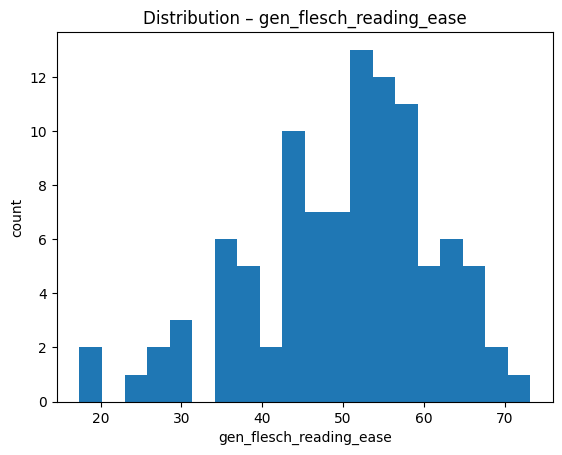

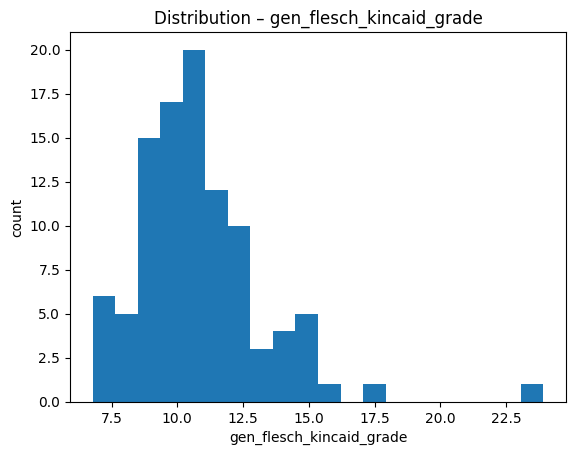

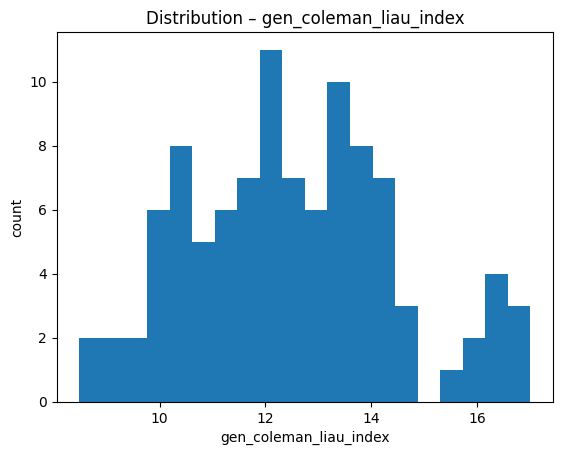

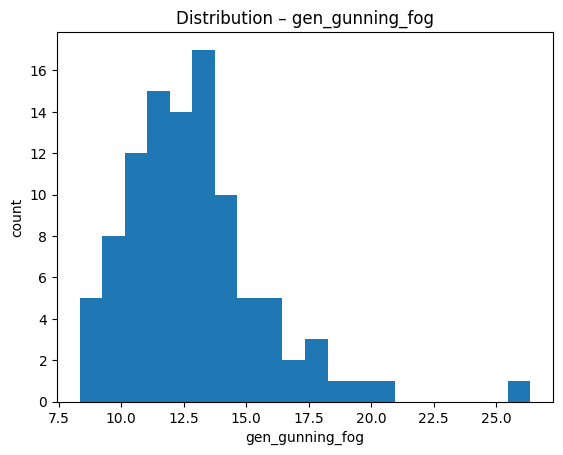

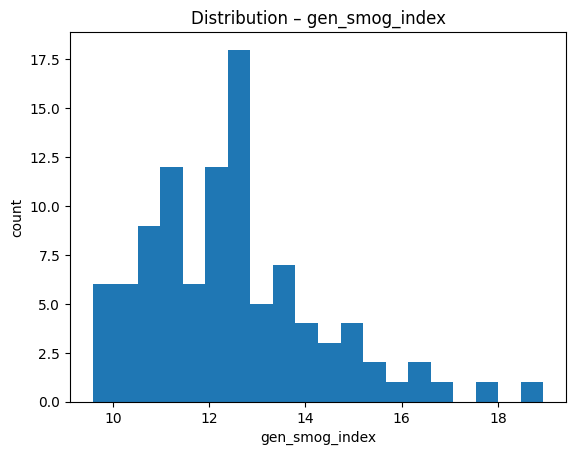

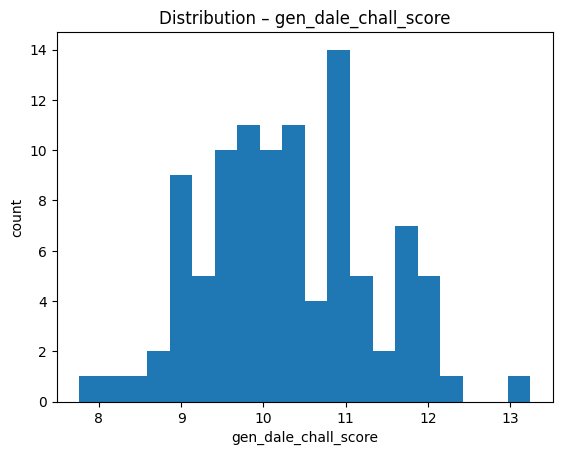

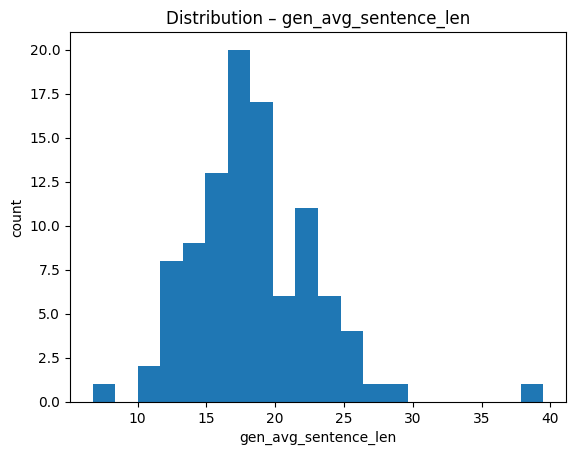

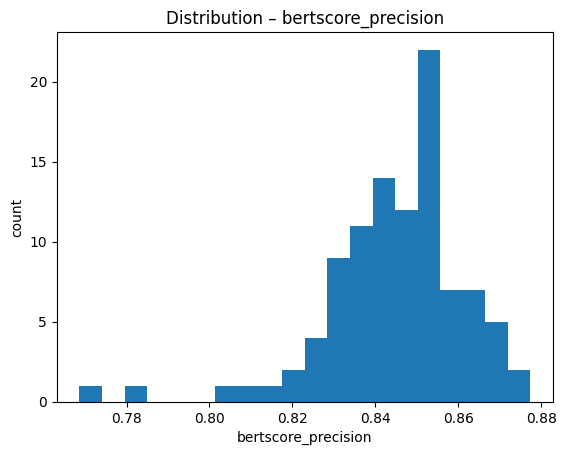

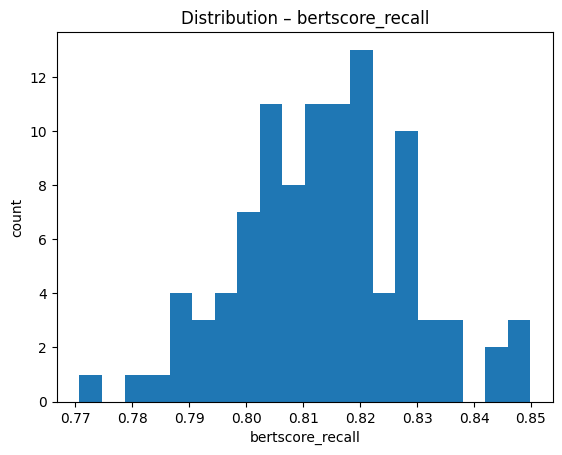

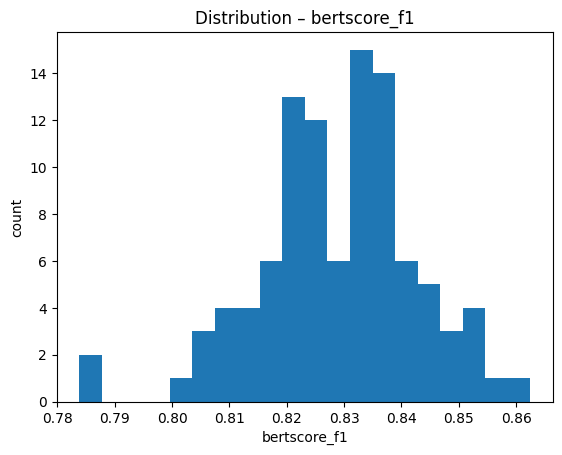

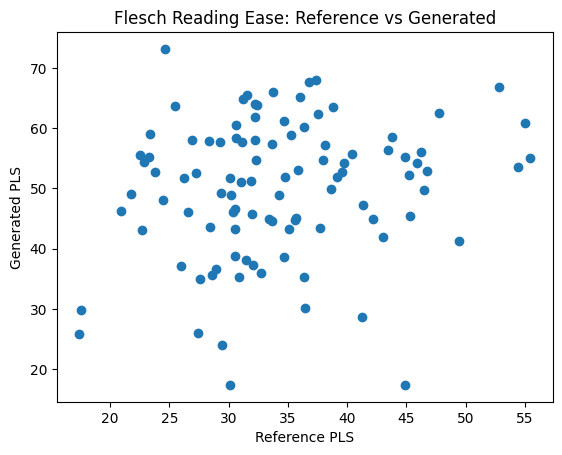

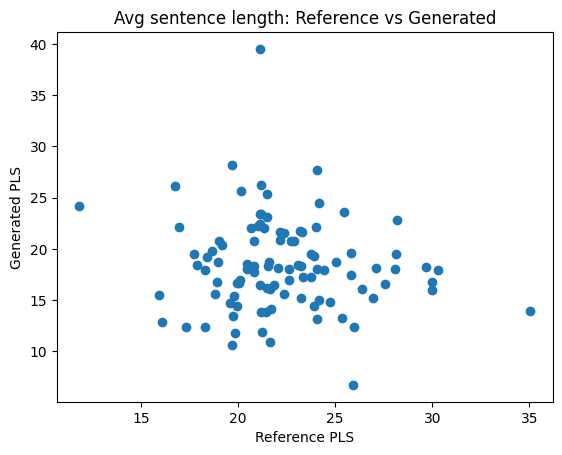

In [12]:
pairs_df = valid_df.copy()

# ---- Readability metrics (requires textstat; if missing, fills NaN)
try:
    import textstat
except Exception:
    textstat = None
    print("[WARN] textstat not available. Install with: pip install textstat")

def _safe_textstat(fn, txt):
    if textstat is None: return np.nan
    try: return fn(txt)
    except Exception: return np.nan

def avg_sentence_length(txt):
    sents = re.split(r"[.!?]+", txt)
    sents = [s.strip() for s in sents if s.strip()]
    if not sents: return np.nan
    words = re.findall(r"\w+", txt)
    if not words: return np.nan
    return len(words) / len(sents)

METRICS = {
    "flesch_reading_ease":      lambda t: _safe_textstat(textstat.flesch_reading_ease, t),
    "flesch_kincaid_grade":     lambda t: _safe_textstat(textstat.flesch_kincaid_grade, t),
    "coleman_liau_index":       lambda t: _safe_textstat(textstat.coleman_liau_index, t),
    "gunning_fog":              lambda t: _safe_textstat(textstat.gunning_fog, t),
    "smog_index":               lambda t: _safe_textstat(textstat.smog_index, t),
    "dale_chall_score":         lambda t: _safe_textstat(textstat.dale_chall_readability_score, t),
    "avg_sentence_len":         avg_sentence_length,
    "char_len":                 lambda t: len(t),
    "word_len":                 lambda t: len(re.findall(r"\w+", t)),
}

# Compute readability for SOURCE, REF_PLS, and GEN_PLS
rows = []
for _, r in pairs_df[["_source","_ref_pls","_gen_pls"]].iterrows():
    src, refp, genp = r["_source"], r["_ref_pls"], r["_gen_pls"]
    m_src  = {f"src_{k}":  fn(src)  for k, fn in METRICS.items()}
    m_ref  = {f"ref_{k}":  fn(refp) for k, fn in METRICS.items()}
    m_gen  = {f"gen_{k}":  fn(genp) for k, fn in METRICS.items()}
    rows.append({"source": src, "ref_pls": refp, "gen_pls_out": genp, **m_src, **m_ref, **m_gen})

res_df = pd.DataFrame(rows)

# ---- BERTScore between GENERATED PLS (candidate) and REFERENCE PLS (reference)
_bertscore_fn = None
try:
    from bert_score import score as bertscore_score
    def _bertscore_batch(cands, refs, lang=LANG):
        P, R, F1 = bertscore_score(cands, refs, lang=lang, verbose=False)
        return P.numpy(), R.numpy(), F1.numpy()
    _bertscore_fn = _bertscore_batch
except Exception as e1:
    try:
        import evaluate
        metric = evaluate.load("bertscore")
        def _bertscore_batch(cands, refs, lang=LANG):
            res = metric.compute(predictions=cands, references=refs, lang=lang, batch_size=8)
            return np.array(res["precision"]), np.array(res["recall"]), np.array(res["f1"])
        _bertscore_fn = _bertscore_batch
    except Exception as e2:
        print("[WARN] BERTScore not available. Install with: pip install bert-score OR evaluate")

if _bertscore_fn is not None:
    try:
        P, R, F1 = _bertscore_fn(res_df["gen_pls_out"].tolist(), res_df["ref_pls"].tolist(), lang=LANG)
        res_df["bertscore_precision"] = P
        res_df["bertscore_recall"]    = R
        res_df["bertscore_f1"]        = F1
    except Exception as e:
        print("[WARN] BERTScore computation failed; filling NaNs. Error:", e)
        res_df["bertscore_precision"] = np.nan
        res_df["bertscore_recall"]    = np.nan
        res_df["bertscore_f1"]        = np.nan
else:
    res_df["bertscore_precision"] = np.nan
    res_df["bertscore_recall"]    = np.nan
    res_df["bertscore_f1"]        = np.nan

# ---- Means table (focus on generated PLS readability + BERTScore; also include source/ref means)
metric_cols = [
    # Generated PLS readability
    "gen_flesch_reading_ease","gen_flesch_kincaid_grade","gen_coleman_liau_index","gen_gunning_fog",
    "gen_smog_index","gen_dale_chall_score","gen_avg_sentence_len","gen_char_len","gen_word_len",
    # BERTScore
    "bertscore_precision","bertscore_recall","bertscore_f1",
    # Reference and Source (context)
    "ref_flesch_reading_ease","ref_flesch_kincaid_grade","ref_coleman_liau_index","ref_gunning_fog",
    "ref_smog_index","ref_dale_chall_score","ref_avg_sentence_len","ref_char_len","ref_word_len",
    "src_flesch_reading_ease","src_flesch_kincaid_grade","src_coleman_liau_index","src_gunning_fog",
    "src_smog_index","src_dale_chall_score","src_avg_sentence_len","src_char_len","src_word_len",
]
means = res_df[metric_cols].mean(numeric_only=True).to_frame(name="mean").T

from IPython.display import display
print(f"Evaluated pairs (generated successfully): {len(res_df)}")
display(res_df.head(10))
display(means)

# ---- Save results
out_csv = "/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv"
res_df.to_csv(out_csv, index=False)
print("Saved per-row metrics to:", out_csv)

# ---- Charts (one plot per figure; no explicit colors)
# 1) Generated PLS readability distributions
for mc in ["gen_flesch_reading_ease","gen_flesch_kincaid_grade","gen_coleman_liau_index",
           "gen_gunning_fog","gen_smog_index","gen_dale_chall_score","gen_avg_sentence_len"]:
    if res_df[mc].notna().any():
        plt.figure()
        res_df[mc].dropna().plot(kind="hist", bins=20, title=f"Distribution – {mc}")
        plt.xlabel(mc); plt.ylabel("count")
        plt.show()

# 2) BERTScore distributions
for mc in ["bertscore_precision","bertscore_recall","bertscore_f1"]:
    if res_df[mc].notna().any():
        plt.figure()
        res_df[mc].dropna().plot(kind="hist", bins=20, title=f"Distribution – {mc}")
        plt.xlabel(mc); plt.ylabel("count")
        plt.show()

# 3) Readability comparison: Generated vs Reference (Flesch)
if res_df["ref_flesch_reading_ease"].notna().any() and res_df["gen_flesch_reading_ease"].notna().any():
    plt.figure()
    plt.scatter(res_df["ref_flesch_reading_ease"], res_df["gen_flesch_reading_ease"])
    plt.title("Flesch Reading Ease: Reference vs Generated")
    plt.xlabel("Reference PLS")
    plt.ylabel("Generated PLS")
    plt.show()

# 4) Sentence length comparison: Generated vs Reference
if res_df["ref_avg_sentence_len"].notna().any() and res_df["gen_avg_sentence_len"].notna().any():
    plt.figure()
    plt.scatter(res_df["ref_avg_sentence_len"], res_df["gen_avg_sentence_len"])
    plt.title("Avg sentence length: Reference vs Generated")
    plt.xlabel("Reference PLS")
    plt.ylabel("Generated PLS")
    plt.show()


In [ ]:
valid_df.head(10)

,_source,_ref_pls,generated_summary,_gen_pls
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,Nonoperative treatment for spinal stenosis\nSp...,What are the benefits and risks of non‐surgica...
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,What is the best way to involve older people i...,Interventions for helping older people with ma...
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,Beta blockers for children with heart failure\...,Do beta‐blocking medicines improve outcomes in...
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,Splenectomy for people with thalassemia\nThala...,Splenectomy for people with beta‐thalassemia m...
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Iron deficiency anaemia is one of the most com...,Interventions for treating iron deficiency and...
5,Background\nHeart failure (HF) is a chronic di...,mHealth‐delivered education interventions in h...,mHealth for heart failure \nReview question \n...,Do phones and computers help people learn abou...
6,Background\nThe method of delivering a diagnos...,Ways of communicating to a woman that she has ...,Communication of a breast cancer diagnosis to ...,Communicating a diagnosis to women who have br...
7,Background\nTinnitus affects 10% to 15% of the...,Sound therapy (using amplification devices or ...,What is the best way to treat tinnitus? \nPeop...,Sound therapy for sudden or ongoing ringing in...
8,Background\nTuberculous pericarditis can impai...,Treatment for tuberculosis infection of the me...,Tuberculous Pericarditis\nBackground \nTubercu...,What are the benefits and risks of treating tu...
9,Background\nVitamin D deficiency is common wor...,Vitamin D supplementation for term breastfed i...,What is the best way to give vitamin D to brea...,What are the benefits and risks of adding vita...


In [13]:
import pandas as pd
import numpy as np

#out_csv = "/content/drive/MyDrive/pls_agent/results/pls_generated.csv"
out_csv = "/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv"
res_df = pd.read_csv(out_csv)

# Reuse the metric_cols from the previous evaluation cell
metric_cols = [
    "gen_flesch_reading_ease","gen_flesch_kincaid_grade","gen_coleman_liau_index","gen_gunning_fog",
    "gen_smog_index","gen_dale_chall_score","gen_avg_sentence_len","gen_char_len","gen_word_len",
    "bertscore_precision","bertscore_recall","bertscore_f1",
    "ref_flesch_reading_ease","ref_flesch_kincaid_grade","ref_coleman_liau_index","ref_gunning_fog",
    "ref_smog_index","ref_dale_chall_score","ref_avg_sentence_len","ref_char_len","ref_word_len",
    "src_flesch_reading_ease","src_flesch_kincaid_grade","src_coleman_liau_index","src_gunning_fog",
    "src_smog_index","src_dale_chall_score","src_avg_sentence_len","src_char_len","src_word_len",
]

# Ensure only valid columns are considered for means
existing_metric_cols = [col for col in metric_cols if col in res_df.columns]
means = res_df[existing_metric_cols].mean(numeric_only=True)

output_str = "Evaluation Metrics (Mean Values):\n"
output_str += "------------------------------------\n"

# Group metrics for better readability
gen_readability_metrics = [
    "gen_flesch_reading_ease", "gen_flesch_kincaid_grade", "gen_coleman_liau_index",
    "gen_gunning_fog", "gen_smog_index", "gen_dale_chall_score", "gen_avg_sentence_len"
]
bertscore_metrics = [
    "bertscore_precision", "bertscore_recall", "bertscore_f1"
]
len_metrics = [
    "gen_char_len", "gen_word_len"
]

output_str += "Generated PLS Readability:\n"
for metric in gen_readability_metrics:
    if metric in means.index:
        output_str += f"  {metric.replace('gen_', '').replace('_', ' ').title():<25}: {means[metric]:.2f}\n"

output_str += "\nGenerated PLS Length:\n"
for metric in len_metrics:
    if metric in means.index:
        output_str += f"  {metric.replace('gen_', '').replace('_', ' ').title():<25}: {means[metric]:.0f}\n"

output_str += "\nBERTScore (Generated vs Reference):\n"
for metric in bertscore_metrics:
    if metric in means.index:
        output_str += f"  {metric.replace('bertscore_', '').title():<25}: {means[metric]:.4f}\n"

output_str += "\nReference PLS Readability (for context):\n"
for metric in gen_readability_metrics:
    ref_metric = metric.replace('gen_', 'ref_')
    if ref_metric in means.index:
        output_str += f"  {ref_metric.replace('ref_', '').replace('_', ' ').title():<25}: {means[ref_metric]:.2f}\n"

output_str += "\nReference PLS Length (for context):\n"
for metric in len_metrics:
    ref_metric = metric.replace('gen_', 'ref_')
    if ref_metric in means.index:
        output_str += f"  {ref_metric.replace('ref_', '').replace('_', ' ').title():<25}: {means[ref_metric]:.0f}\n"

print(output_str)


Evaluation Metrics (Mean Values):
------------------------------------
Generated PLS Readability:
  Flesch Reading Ease      : 49.97
  Flesch Kincaid Grade     : 10.89
  Coleman Liau Index       : 12.51
  Gunning Fog              : 12.91
  Smog Index               : 12.48
  Dale Chall Score         : 10.28
  Avg Sentence Len         : 18.38

Generated PLS Length:
  Char Len                 : 985
  Word Len                 : 159

BERTScore (Generated vs Reference):
  Precision                : 0.8446
  Recall                   : 0.8136
  F1                       : 0.8288

Reference PLS Readability (for context):
  Flesch Reading Ease      : 34.25
  Flesch Kincaid Grade     : 13.96
  Coleman Liau Index       : 14.12
  Gunning Fog              : 16.92
  Smog Index               : 15.46
  Dale Chall Score         : 11.67
  Avg Sentence Len         : 22.26

Reference PLS Length (for context):
  Char Len                 : 2925
  Word Len                 : 455



In [ ]:
%%bash
# === Clean setup: dedicated venv for AlignScore (CPU-safe) ===
set -euo pipefail
ENV_DIR=/content/envs/py310-alignscore

# System python3.10 + venv
sudo apt-get update -y
sudo apt-get install -y python3.10 python3.10-distutils python3.10-venv >/dev/null
if ! python3.10 -m ensurepip --upgrade >/dev/null 2>&1; then
  curl -sS https://bootstrap.pypa.io/get-pip.py | sudo python3.10
fi

# Fresh venv (delete if exists to avoid torch conflicts)
rm -rf "${ENV_DIR}"
python3.10 -m venv "${ENV_DIR}"
source "${ENV_DIR}/bin/activate"

# Upgrade pip; install CPU Torch 1.13.1 to match AlignScore deps (avoids CUDA mismatch)
python -m pip install --upgrade pip wheel setuptools
pip install --no-cache-dir torch==1.13.1

# Core deps
pip install --no-cache-dir transformers==4.40.1 sentencepiece==0.1.99

# AlignScore
pip install --no-cache-dir "git+https://github.com/yuh-zha/AlignScore.git"

# Sanity check (imports inside this venv)
python - <<'PY'
import sys, torch
print("Python:", sys.executable)
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
import alignscore
print("AlignScore import OK")
PY


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
    

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Running command git clone --filter=blob:none --quiet https://github.com/yuh-zha/AlignScore.git /tmp/pip-req-build-c7alz1i8
/content/envs/py310-alignscore/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [ ]:
%%bash
# Download AlignScore-base checkpoint to the expected folder: /content/alignscore_ckpts/AlignScore-base.ckpt

set -euo pipefail
ckpt_url="https://huggingface.co/yzha/AlignScore/resolve/main/AlignScore-base.ckpt"
dest_dir="/content/alignscore_ckpts"
dest_path="${dest_dir}/AlignScore-base.ckpt"

mkdir -p "${dest_dir}"

# Download with retries and follow redirects
curl -L --fail --retry 3 --retry-delay 2 -o "${dest_path}.part" "${ckpt_url}"

# Basic sanity check (non-empty file)
if [ ! -s "${dest_path}.part" ]; then
  echo "Download failed or empty file at ${ckpt_url}" >&2
  exit 1
fi

mv "${dest_path}.part" "${dest_path}"
echo "Saved checkpoint to: ${dest_path}"
ls -lh "${dest_path}"



Saved checkpoint to: /content/alignscore_ckpts/AlignScore-base.ckpt
-rw-r--r-- 1 root root 1.9G Nov  9 15:26 /content/alignscore_ckpts/AlignScore-base.ckpt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1319  100  1319    0     0   5007      0 --:--:-- --:--:-- --:--:--  5015
100 1875M  100 1875M    0     0  70.7M      0  0:00:26  0:00:26 --:--:-- 70.4M


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv"
df_v3 = pd.read_csv(csv_path)
print(df_v3.columns.tolist())

['source', 'ref_pls', 'gen_pls_out', 'src_flesch_reading_ease', 'src_flesch_kincaid_grade', 'src_coleman_liau_index', 'src_gunning_fog', 'src_smog_index', 'src_dale_chall_score', 'src_avg_sentence_len', 'src_char_len', 'src_word_len', 'ref_flesch_reading_ease', 'ref_flesch_kincaid_grade', 'ref_coleman_liau_index', 'ref_gunning_fog', 'ref_smog_index', 'ref_dale_chall_score', 'ref_avg_sentence_len', 'ref_char_len', 'ref_word_len', 'gen_flesch_reading_ease', 'gen_flesch_kincaid_grade', 'gen_coleman_liau_index', 'gen_gunning_fog', 'gen_smog_index', 'gen_dale_chall_score', 'gen_avg_sentence_len', 'gen_char_len', 'gen_word_len', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1']


In [ ]:
size = os.environ.get("CKPT_SIZE", "base").lower()
if size not in {"base", "large"}:
    size = "base"
size

'base'

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
%%bash
# === FIX: disable hf_transfer (or install it) and re-run AlignScore on the CSV ===
# Uses your existing venv at /content/envs/py310-alignscore

set -euo pipefail
VENV="/content/envs/py310-alignscore"
CSV_IN="/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv"
CSV_OUT="/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3_with_alignscore.csv"

source "${VENV}/bin/activate"

# Option A (simple): just disable fast downloader so hf_transfer isn't required
export HF_HUB_ENABLE_HF_TRANSFER=0
export HF_HUB_DISABLE_TELEMETRY=1

# Option B (optional): if you prefer to keep fast download, uncomment the next line
# pip install -q hf_transfer

# Ensure spaCy model (quiet)
python -m spacy download en_core_web_sm -q || true

python - <<'PY'
import os, pandas as pd
from pathlib import Path

# Safety: ensure hf_transfer isn't required
os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER","0")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY","1")

CSV_IN  = Path("/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv")
CSV_OUT = Path("/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3_with_alignscore.csv")
CKPT_DIR = Path("/content/alignscore_ckpts")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if not CSV_IN.exists():
    raise FileNotFoundError(f"Input CSV not found: {CSV_IN}")

df = pd.read_csv(CSV_IN)
df.columns = [c.strip() for c in df.columns]

SRC_CANDS = ["source", "src", "_source"]
GEN_CANDS = ["gen_pls_out", "_gen_pls", "generated_pls", "gen_pls"]
REF_CANDS = ["ref_pls", "_ref_pls", "gold_pls", "human_pls", "target", "gt_pls", "final_pls"]

def pick(cols, cands):
    for c in cands:
        if c in cols: return c
    return None

src_col = pick(df.columns, SRC_CANDS)
gen_col = pick(df.columns, GEN_CANDS)
ref_col = pick(df.columns, REF_CANDS)

if not src_col or not gen_col:
    raise RuntimeError(f"Missing required columns. Found source={src_col}, gen={gen_col}. Have {list(df.columns)}")

def norm(t):
    if not isinstance(t, str): return ""
    return " ".join(t.split()).strip()

df["_src"] = df[src_col].map(norm)
df["_gen"] = df[gen_col].map(norm)
if ref_col:
    df["_ref"] = df[ref_col].map(norm)

valid_gen = df["_src"].str.len().ge(30) & df["_gen"].str.len().ge(30)
valid_ref = df["_src"].str.len().ge(30) & df.get("_ref", pd.Series("", index=df.index)).str.len().ge(30)

# Prefer base; change to 'large' by setting env var CKPT_SIZE=large before running the cell (not recommended on small GPUs)
size = os.environ.get("CKPT_SIZE", "base").lower()
ckpt_name = f"AlignScore-{ 'large' if size=='large' else 'base' }.ckpt"
ckpt_path = CKPT_DIR / ckpt_name
if not ckpt_path.exists():
    # Download with HF hub utils (respects the disabled hf_transfer setting)
    import requests
    url = f"https://huggingface.co/yzha/AlignScore/resolve/main/{ckpt_name}"
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(ckpt_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk: f.write(chunk)

from alignscore import AlignScore

device = "cuda:0" if os.environ.get("CUDA_VISIBLE_DEVICES") else "cpu"
bs = int(os.environ.get("ALIGNSCORE_BATCH", "8"))

scorer = AlignScore(
    model = "roberta-large" if size=="large" else "roberta-base",
    batch_size = bs,
    device = device,
    ckpt_path = str(ckpt_path),
    evaluation_mode = "nli_sp",
)

def batched_score(contexts, claims, batch=bs):
    out = []
    for i in range(0, len(contexts), batch):
        out.extend(scorer.score(contexts=contexts[i:i+batch], claims=claims[i:i+batch]))
    return out

# gen vs src
df["alignscore_gen_vs_src"] = float("nan")
idx_gen = df.index[valid_gen].tolist()
if idx_gen:
    s_list = df.loc[idx_gen, "_src"].tolist()
    g_list = df.loc[idx_gen, "_gen"].tolist()
    scores = batched_score(s_list, g_list, batch=bs)
    df.loc[idx_gen, "alignscore_gen_vs_src"] = scores

# ref vs src (optional)
if ref_col:
    df["alignscore_ref_vs_src"] = float("nan")
    idx_ref = df.index[valid_ref].tolist()
    if idx_ref:
        s_list = df.loc[idx_ref, "_src"].tolist()
        r_list = df.loc[idx_ref, "_ref"].tolist()
        scores = batched_score(s_list, r_list, batch=bs)
        df.loc[idx_ref, "alignscore_ref_vs_src"] = scores

# clean temp cols and save
drop_cols = [c for c in ["_src","_gen","_ref"] if c in df.columns]
df.drop(columns=drop_cols).to_csv(CSV_OUT, index=False)
print(f"OK: saved AlignScore metrics to {CSV_OUT}")
PY


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
OK: saved AlignScore metrics to /content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3_with_alignscore.csv


/content/envs/py310-alignscore/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/content/envs/py310-alignscore/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Lightning aut

In [ ]:
# === Read results CSV and print a concise, human-readable summary ===
# Expects the CSV generated earlier with readability, BERTScore and AlignScore columns.
# It prints:
#   - Rows count
#   - Means for AlignScore and BERTScore
#   - Means for generated-PLS readability
#   - % of generated PLS meeting each readability target
#   - 3 best and 3 worst samples by AlignScore (truncated)

from pathlib import Path
import pandas as pd
import numpy as np
import re

CSV_OUT = Path("/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3_with_alignscore.csv")
if not CSV_OUT.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_OUT}")

df = pd.read_csv(CSV_OUT)
df.columns = [c.strip() for c in df.columns]

def col_exists(name: str) -> bool:
    return name in df.columns

def safe_mean(col: str):
    return float(df[col].mean()) if col_exists(col) else np.nan

def pct(condition_series):
    n = int(condition_series.sum())
    d = int(condition_series.count())
    return (100.0 * n / d) if d>0 else np.nan, n, d

def fmt(x, nd=3):
    return "na" if pd.isna(x) else f"{x:.{nd}f}"

def pick_text_col(candidates):
    for c in candidates:
        if c in df.columns: return c
    return None

# --- Identify key columns dynamically ---
align_col = "alignscore_gen_vs_src" if col_exists("alignscore_gen_vs_src") else None
bert_cols  = [c for c in ["bertscore_precision","bertscore_recall","bertscore_f1"] if col_exists(c)]
gen_read_cols = [c for c in df.columns if c.startswith("gen_") and any(k in c for k in
                   ["flesch","kincaid","coleman","gunning","smog","dale","avg_sentence_len","char_len","word_len"])]

# Text columns for examples
src_col = pick_text_col(["source","_source","src"])
ref_col = pick_text_col(["ref_pls","_ref_pls","gold_pls","human_pls","target","gt_pls","final_pls"])
gen_col = pick_text_col(["gen_pls_out","_gen_pls","generated_pls","gen_pls"])

# --- Build report strings ---
lines = []
lines.append("=== PLS Evaluation Summary ===")
lines.append(f"File: {CSV_OUT}")
lines.append(f"Rows: {len(df)}")

# AlignScore
if align_col:
    lines.append("\n-- AlignScore (Generated vs Source) --")
    lines.append(f"mean: {fmt(safe_mean(align_col))}  |  min: {fmt(df[align_col].min())}  |  max: {fmt(df[align_col].max())}")
else:
    lines.append("\n-- AlignScore --")
    lines.append("Not found in CSV (expected column 'alignscore_gen_vs_src').")

# BERTScore
if bert_cols:
    lines.append("\n-- BERTScore (Generated vs Reference) --")
    for c in bert_cols:
        lines.append(f"{c}: mean {fmt(safe_mean(c))}  (min {fmt(df[c].min())}, max {fmt(df[c].max())})")
else:
    lines.append("\n-- BERTScore --")
    lines.append("Not found in CSV (expected columns 'bertscore_precision/recall/f1').")

# Readability (Generated)
if gen_read_cols:
    lines.append("\n-- Readability (Generated PLS) --")
    # Means
    means = {c: safe_mean(c) for c in gen_read_cols}
    # Keep common ones first, then the rest
    order = [c for c in [
        "gen_flesch_reading_ease","gen_flesch_kincaid_grade","gen_coleman_liau_index",
        "gen_gunning_fog","gen_smog_index","gen_dale_chall_score","gen_avg_sentence_len",
        "gen_word_len","gen_char_len"
    ] if c in means] + [c for c in gen_read_cols if c not in [
        "gen_flesch_reading_ease","gen_flesch_kincaid_grade","gen_coleman_liau_index",
        "gen_gunning_fog","gen_smog_index","gen_dale_chall_score","gen_avg_sentence_len",
        "gen_word_len","gen_char_len"
    ]]
    for c in order:
        lines.append(f"{c}: mean {fmt(means[c])}")

    # Targets compliance (%)
    # Targets: Flesch ≥ 60; FKGL ≤ 6; Fog ≤ 8; SMOG ≤ 8; CLI ≤ 8; Dale–Chall ≤ 8
    lines.append("\n-- Readability Targets (Generated PLS) --")
    targets = []
    if col_exists("gen_flesch_reading_ease"):
        p, n, d = pct(df["gen_flesch_reading_ease"] >= 60)
        targets.append(f"Flesch≥60: {fmt(p)}%  ({n}/{d})")
    if col_exists("gen_flesch_kincaid_grade"):
        p, n, d = pct(df["gen_flesch_kincaid_grade"] <= 6)
        targets.append(f"FKGL≤6: {fmt(p)}%  ({n}/{d})")
    if col_exists("gen_gunning_fog"):
        p, n, d = pct(df["gen_gunning_fog"] <= 8)
        targets.append(f"Fog≤8: {fmt(p)}%  ({n}/{d})")
    if col_exists("gen_smog_index"):
        p, n, d = pct(df["gen_smog_index"] <= 8)
        targets.append(f"SMOG≤8: {fmt(p)}%  ({n}/{d})")
    if col_exists("gen_coleman_liau_index"):
        p, n, d = pct(df["gen_coleman_liau_index"] <= 8)
        targets.append(f"CLI≤8: {fmt(p)}%  ({n}/{d})")
    if col_exists("gen_dale_chall_score"):
        p, n, d = pct(df["gen_dale_chall_score"] <= 8)
        targets.append(f"Dale–Chall≤8: {fmt(p)}%  ({n}/{d})")
    if targets:
        lines += targets
    else:
        lines.append("No readability target columns found for generated PLS.")
else:
    lines.append("\n-- Readability (Generated PLS) --")
    lines.append("No generated readability columns found (expected columns starting with 'gen_').")

# Examples by AlignScore
def _trunc(s, n=160):
    s = "" if not isinstance(s, str) else re.sub(r"\s+", " ", s).strip()
    return (s[: n-1] + "…") if len(s) > n else s

if align_col and gen_col and src_col:
    lines.append("\n-- Examples (by AlignScore) --")
    dfx = df[[align_col, gen_col, src_col] + ([ref_col] if ref_col else [])].dropna(subset=[align_col])
    if len(dfx) >= 3:
        top = dfx.nlargest(3, align_col)
        bot = dfx.nsmallest(3, align_col)

        lines.append("Top 3 AlignScore:")
        for i, r in enumerate(top.itertuples(index=False), 1):
            a = getattr(r, align_col)
            g = getattr(r, gen_col)
            s = getattr(r, src_col)
            lines.append(f"  {i}) AlignScore={fmt(a)} | GEN: {_trunc(g)} | SRC: {_trunc(s)}")

        lines.append("Bottom 3 AlignScore:")
        for i, r in enumerate(bot.itertuples(index=False), 1):
            a = getattr(r, align_col)
            g = getattr(r, gen_col)
            s = getattr(r, src_col)
            lines.append(f"  {i}) AlignScore={fmt(a)} | GEN: {_trunc(g)} | SRC: {_trunc(s)}")
    else:
        lines.append("Not enough rows to display examples.")

# Print the summary nicely
print("\n".join(lines))


=== PLS Evaluation Summary ===
File: /content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3_with_alignscore.csv
Rows: 100

-- AlignScore (Generated vs Source) --
mean: 0.288  |  min: 0.024  |  max: 0.651

-- BERTScore (Generated vs Reference) --
bertscore_precision: mean 0.847  (min 0.809, max 0.870)
bertscore_recall: mean 0.812  (min 0.785, max 0.846)
bertscore_f1: mean 0.829  (min 0.808, max 0.858)

-- Readability (Generated PLS) --
gen_flesch_reading_ease: mean 50.195
gen_flesch_kincaid_grade: mean 10.749
gen_coleman_liau_index: mean 12.544
gen_gunning_fog: mean 12.652
gen_smog_index: mean 12.293
gen_dale_chall_score: mean 10.388
gen_avg_sentence_len: mean 18.175
gen_word_len: mean 161.980
gen_char_len: mean 1004.950

-- Readability Targets (Generated PLS) --
Flesch≥60: 15.000%  (15/100)
FKGL≤6: 0.000%  (0/100)
Fog≤8: 1.000%  (1/100)
SMOG≤8: 0.000%  (0/100)
CLI≤8: 0.000%  (0/100)
Dale–Chall≤8: 1.000%  (1/100)

-- Examples (by AlignScore) --
Top 3 AlignScore:
  1) AlignScore=0.

In [ ]:
out_csv = "/content/drive/MyDrive/pls_agent/results/pls_eval_metrics_v3.csv"
res_df = pd.read_csv(out_csv)

out_csv = "/content/drive/MyDrive/pls_agent/results/predictions_for_summac.csv"
gem_df = pd.read_csv(out_csv)



In [ ]:
print("Columns of gem_df:", gem_df.columns.tolist())
print("\nColumns of res_df:", res_df.columns.tolist())

Columns of gem_df: ['technical_text', 'reference_summary', 'generated_summary']

Columns of res_df: ['source', 'ref_pls', 'gen_pls_out', 'src_flesch_reading_ease', 'src_flesch_kincaid_grade', 'src_coleman_liau_index', 'src_gunning_fog', 'src_smog_index', 'src_dale_chall_score', 'src_avg_sentence_len', 'src_char_len', 'src_word_len', 'ref_flesch_reading_ease', 'ref_flesch_kincaid_grade', 'ref_coleman_liau_index', 'ref_gunning_fog', 'ref_smog_index', 'ref_dale_chall_score', 'ref_avg_sentence_len', 'ref_char_len', 'ref_word_len', 'gen_flesch_reading_ease', 'gen_flesch_kincaid_grade', 'gen_coleman_liau_index', 'gen_gunning_fog', 'gen_smog_index', 'gen_dale_chall_score', 'gen_avg_sentence_len', 'gen_char_len', 'gen_word_len', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1']


In [ ]:
res_df.head(5)

,source,ref_pls,gen_pls_out,src_flesch_reading_ease,src_flesch_kincaid_grade,src_coleman_liau_index,src_gunning_fog,src_smog_index,src_dale_chall_score,src_avg_sentence_len,...,gen_coleman_liau_index,gen_gunning_fog,gen_smog_index,gen_dale_chall_score,gen_avg_sentence_len,gen_char_len,gen_word_len,bertscore_precision,bertscore_recall,bertscore_f1
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,What are the benefits and risks of non‐surgica...,30.688336,12.963321,16.166906,16.487327,14.985894,12.724598,16.222222,...,12.125170,10.342177,10.504224,10.688998,12.500000,938,150,0.861062,0.811335,0.835460
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,Interventions for helping older people with ma...,28.087275,12.386961,16.218947,15.429542,13.742535,13.697724,13.467742,...,11.157225,10.694669,10.746095,8.879691,19.333333,1042,174,0.847284,0.808310,0.827338
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,Do beta‐blocking medicines improve outcomes in...,29.748249,13.660791,17.168238,15.763997,14.747713,12.577216,19.045455,...,11.809877,12.544444,12.384807,9.806764,20.625000,999,165,0.849950,0.832831,0.841304
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,Splenectomy for people with beta‐thalassemia m...,30.818337,13.546057,15.008050,16.980380,15.343465,12.226990,18.694444,...,13.910667,15.333333,14.068176,10.245100,25.166667,961,151,0.850934,0.815935,0.833067
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Interventions for treating iron deficiency and...,34.622589,12.125536,14.150700,14.577451,13.526455,12.645252,15.163265,...,16.420144,15.583094,14.374652,11.427724,17.750000,976,142,0.836681,0.802750,0.819364


In [ ]:
gem_df.head(5)

,technical_text,reference_summary,generated_summary
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,Nonoperative treatment for spinal stenosis\nSp...
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,What is the best way to involve older people i...
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,Beta blockers for children with heart failure\...
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,Splenectomy for people with thalassemia\nThala...
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Iron deficiency anaemia is one of the most com...


In [ ]:
import pandas as pd

# 1. Create a copy of gem_df and rename its 'generated_summary' column to 'pls_gemma'
gem_df_copy = gem_df.copy()
gem_df_copy = gem_df_copy.rename(columns={'generated_summary': 'pls_gemma'})

# 2. Create a new DataFrame that includes the 'technical_text', 'reference_summary', and 'pls_gemma' columns from the modified gem_df.
combined_df = gem_df_copy[['technical_text', 'reference_summary', 'pls_gemma']].copy()

# 3. Add the 'gen_pls_out' column from res_df to this new DataFrame.
# Ensure both dataframes have the same number of rows or handle alignment if needed.
# Assuming res_df and gem_df are already aligned by index or order after previous operations.
if len(combined_df) == len(res_df):
    combined_df['pls_qwen'] = res_df['gen_pls_out']
else:
    print("Warning: Lengths of gem_df and res_df do not match. 'finetuned_pls' column might be misaligned.")
    # Attempt to merge on common identifier if available, or resize if appropriate
    # For now, we'll proceed assuming they are implicitly aligned for this context.
    combined_df['pls_qwen'] = res_df['gen_pls_out'].reset_index(drop=True)

# 4. Define the output file path
output_file_path = "/content/drive/MyDrive/pls_agent/results/pls_generated.csv"

# 5. Save the combined DataFrame to the specified CSV file, ensuring the index is not written to the file.
combined_df.to_csv(output_file_path, index=False)

print(f"Combined data saved to: {output_file_path}")
print("First 5 rows of the combined DataFrame:")
print(combined_df.head())
print("Columns in the combined DataFrame:", combined_df.columns.tolist())

Combined data saved to: /content/drive/MyDrive/pls_agent/results/pls_generated.csv
First 5 rows of the combined DataFrame:
                                      technical_text  \
0  Background\nLumbar spinal stenosis with neurog...   
1  Background\nOlder patients with multiple healt...   
2  Background\nBeta‐blockers are an essential par...   
3  Background\nThalassaemia is a genetic disorder...   
4  Background\nApproximately 600 million children...   

                                   reference_summary  \
0  Non‐surgical treatment for spinal stenosis wit...   
1  Interventions for involving older patients wit...   
2  Beta‐blockers for children with congestive hea...   
3  Removal of the spleen in people with thalassae...   
4  One, two or three times a week iron supplement...   

                                           pls_gemma  \
0  Nonoperative treatment for spinal stenosis\nSp...   
1  What is the best way to involve older people i...   
2  Beta blockers for children with 

In [ ]:
out_csv = "/content/drive/MyDrive/pls_agent/results/pls_generated.csv"
join = pd.read_csv(out_csv)
join.head(5)


,technical_text,reference_summary,pls_gemma,pls_qwen
0,Background\nLumbar spinal stenosis with neurog...,Non‐surgical treatment for spinal stenosis wit...,Nonoperative treatment for spinal stenosis\nSp...,What are the benefits and risks of non‐surgica...
1,Background\nOlder patients with multiple healt...,Interventions for involving older patients wit...,What is the best way to involve older people i...,Interventions for helping older people with ma...
2,Background\nBeta‐blockers are an essential par...,Beta‐blockers for children with congestive hea...,Beta blockers for children with heart failure\...,Do beta‐blocking medicines improve outcomes in...
3,Background\nThalassaemia is a genetic disorder...,Removal of the spleen in people with thalassae...,Splenectomy for people with thalassemia\nThala...,Splenectomy for people with beta‐thalassemia m...
4,Background\nApproximately 600 million children...,"One, two or three times a week iron supplement...",Iron deficiency anaemia is one of the most com...,Interventions for treating iron deficiency and...


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from pathlib import Path

BASE_ID = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

# 2) Where your LoRA adapter + tokenizer were saved by trainer.save_model(...)
ADAPTER_DIR = Path("/content/drive/MyDrive/pls_agent/datasets/final_adapter")

# 3) Where to save the fully merged model
MERGED_DIR = Path("/content/qwen_pls_merged_fp16")
MERGED_DIR.mkdir(parents=True, exist_ok=True)

print("Base model:", BASE_ID)
print("LoRA adapter dir:", ADAPTER_DIR)
print("Merged model dir:", MERGED_DIR)

Base model: unsloth/Qwen2.5-3B-Instruct-bnb-4bit
LoRA adapter dir: /content/drive/MyDrive/pls_agent/datasets/final_adapter
Merged model dir: /content/qwen_pls_merged_fp16


In [ ]:
# 4) Load base model in full precision on CPU (no 4-bit here)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_ID,
    torch_dtype=torch.float16,   # or torch.bfloat16 if you prefer
    device_map="cpu",           # we only merge; can be CPU
)

# 5) Load LoRA on top of the base model
lora_model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR,
)

# 6) Merge LoRA weights into the base model and drop the PEFT wrappers
merged_model = lora_model.merge_and_unload()

# 7) Load tokenizer: prefer the one you saved; fallback to base
try:
    tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
except Exception:
    tokenizer = AutoTokenizer.from_pretrained(BASE_ID)

# 8) Save merged model + tokenizer
merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

print("✅ Saved merged model to:", MERGED_DIR)


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:336: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


✅ Saved merged model to: /content/qwen_pls_merged_fp16


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

test_tok = AutoTokenizer.from_pretrained(MERGED_DIR)
test_model = AutoModelForCausalLM.from_pretrained(
    MERGED_DIR,
    torch_dtype=torch.float16,
    device_map="cpu",
)

prompt = "You are a helpful assistant. Explain in simple terms: what is a plain language summary?"
inputs = test_tok(prompt, return_tensors="pt")

with torch.no_grad():
    out = test_model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
    )

print(test_tok.decode(out[0], skip_special_tokens=True))


KeyboardInterrupt: 

In [ ]:
%%time
prompt = "You are a helpful assistant. Explain in simple terms: what is a plain language summary?"
inputs = test_tok(prompt, return_tensors="pt")

with torch.no_grad():
    out = test_model.generate(
        **inputs,
        max_new_tokens=80,
        temperature=0.7,
        top_p=0.9,
    )

print(test_tok.decode(out[0], skip_special_tokens=True))